# Optimizacion de portafolios: modelo Media-Varianza y Risk Parity

Construccion y comparacion de carteras optimas sobre un universo de 18 activos
(acciones individuales, ETFs sectoriales SPDR y renta fija del Tesoro), evaluando
tres funciones objetivo distintas del modelo clasico de Markowitz y contrastandolas
con una asignacion por paridad de riesgo.

**Pregunta:** dado un universo de activos con estructura de correlaciones conocida,
que asignacion resulta optima segun cada funcion objetivo, y cuanto de esa diferencia
viene del metodo y cuanto de la fragilidad de los estimadores.

**Fuente:** Yahoo Finance via `yfinance`, precios ajustados, ventana de 5 anos.

Segunda parte de la clase: Armamos un portafolio

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
tickers = ['AAPL', 'IEF', 'PG', 'SPY', 'VZ', 'KO', 'XLF', 'XLK', 'XLU', 'XLE', 'XLI', 'XLP', 'XLY', 'XLB', 'XLV', 'XLC', 'XLRE', 'BAC']

# PG: Procter & Gamble, Multinacional de productos de consumo
# VZ: Verizon Communications, Empresa de telecomunicaciones
# BAC: Bank of America, Uno de los bancos más grandes de EE.UU
# IEF: iShares 7–10 Year Treasury Bond ETF, ETF que invierte en bonos del Tesoro de EE.UU
# SPY: SPDR S&P 500 ETF Trust, ETF que replica el S&P 500
# XLF: Financial Select Sector SPDR Fund, Sector financiero
# XLK: Technology Select Sector SPDR Fund, Sector financiero
# XLU: Utilities Select Sector SPDR Fund, Sector servicios públicos
# XLE: Energy Select Sector SPDR Fund, Sector energía
# XLI: Industrial Select Sector SPDR Fund, Sector industrial
# XLP: Consumer Staples Select Sector SPDR Fund, Sector consumo básico
# XLY: Consumer Discretionary Select Sector SPDR Fund, Sector consumo discrecional
# XLB: Materials Select Sector SPDR Fund, Sector materiales
# XLV: Health Care Select Sector SPDR Fund, Sector salud
# XLC: Communication Services Select Sector SPDR Fund, Sector comunicaciones
# XLRE: Real Estate Select Sector SPDR Fund, Sector inmobiliario

# acciones: AAPL, PG, VZ, KO, BAC
# ETFs: IEF, SPY, XLF, XLK, XLU, XLE, XLI, XLP, XLY, XLB, XLV, XLC, XLRE

In [ ]:
df = yf.download(tickers, period='5y', auto_adjust=False)['Adj Close']
df

# auto_adjust=False, cuando es False, los precios quedan tal como se negociaron en el mercado
# ['Adj Close'], precio ajustado por eventos corporativos, como:dividendos y stock splits

[*********************100%***********************]  18 of 18 completed


Ticker,AAPL,BAC,IEF,KO,PG,SPY,VZ,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Date,,,,,,,,,,,,,,,,,,
2021-03-08,113.334129,32.883469,99.957443,44.428368,112.220238,356.326660,41.813450,34.548134,68.913696,21.957661,31.313242,87.467056,60.506012,56.979713,31.288845,25.985016,104.084450,75.407997
2021-03-09,117.941132,32.166103,100.431091,43.757301,111.224174,361.414062,41.379044,34.760887,69.684769,21.572725,31.028908,87.105789,62.564064,56.927101,31.643824,26.328506,104.693802,78.256020
2021-03-10,116.859985,33.096020,100.641556,44.256302,112.246666,363.663727,42.026981,35.335781,69.979897,22.119081,31.661795,88.393440,62.314022,57.672443,31.956549,26.508842,104.933807,78.654655
2021-03-11,118.788513,32.980892,100.606453,43.774509,111.867653,367.350891,40.871014,35.525909,71.303154,22.127359,31.570057,88.458282,63.645996,57.532146,32.429852,26.440144,105.570847,79.860138
2021-03-12,117.882675,33.600822,99.878532,43.687759,112.951866,367.845703,40.959370,35.620972,71.103241,22.172890,31.891077,89.644005,63.189178,58.005665,32.987682,26.796513,105.801659,80.095482
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-02,264.720001,49.530003,97.120003,80.220001,163.509995,686.380005,49.980000,53.250000,117.870003,57.040001,51.299999,178.899994,139.539993,88.709999,43.919998,47.369999,158.529999,115.419998
2026-03-03,263.750000,49.689102,97.010002,79.339996,159.720001,680.330017,50.869999,51.939999,117.959999,56.520000,51.209999,175.440002,137.500000,87.739998,43.700001,47.070000,156.740005,114.360001
2026-03-04,262.519989,50.017242,96.809998,78.099998,158.300003,685.130005,51.200001,51.919998,118.790001,56.189999,51.500000,175.970001,139.839996,87.160004,43.759998,47.270000,157.050003,116.389999


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1256 entries, 2021-03-08 to 2026-03-06
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    1256 non-null   float64
 1   BAC     1256 non-null   float64
 2   IEF     1256 non-null   float64
 3   KO      1256 non-null   float64
 4   PG      1256 non-null   float64
 5   SPY     1256 non-null   float64
 6   VZ      1256 non-null   float64
 7   XLB     1256 non-null   float64
 8   XLC     1256 non-null   float64
 9   XLE     1256 non-null   float64
 10  XLF     1256 non-null   float64
 11  XLI     1256 non-null   float64
 12  XLK     1256 non-null   float64
 13  XLP     1256 non-null   float64
 14  XLRE    1256 non-null   float64
 15  XLU     1256 non-null   float64
 16  XLV     1256 non-null   float64
 17  XLY     1256 non-null   float64
dtypes: float64(18)
memory usage: 186.4 KB


In [ ]:
len(df.columns)
tickers

# len(df.columns), cuenta cuántos activos hay en el DataFrame

['AAPL',
 'IEF',
 'PG',
 'SPY',
 'VZ',
 'KO',
 'XLF',
 'XLK',
 'XLU',
 'XLE',
 'XLI',
 'XLP',
 'XLY',
 'XLB',
 'XLV',
 'XLC',
 'XLRE',
 'BAC']

Equally weighted portfolio

In [ ]:
# Asignando los mismos pesos a la cartera con todos los activos: Equally weighted portfolio
weights = pd.Series([1/18]*18, index=df.columns)
weights

# pd.Series, crea una serie de datos de pandas, que es como una columna con valores y etiquetas. En este caso se usa para crear los pesos del portafolio
# [1/18]*18, crea una lista con 18 valores iguales

,0
Ticker,
AAPL,0.055556
BAC,0.055556
IEF,0.055556
KO,0.055556
PG,0.055556
SPY,0.055556
VZ,0.055556
XLB,0.055556
XLC,0.055556


In [ ]:
#calculo variacion porcentual
y=df.pct_change().dropna()
y

# .dropna(), elimina filas que tengan valores vacíos (NaN)

Ticker,AAPL,BAC,IEF,KO,PG,SPY,VZ,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Date,,,,,,,,,,,,,,,,,,
2021-03-09,0.040650,-0.021815,0.004738,-0.015104,-0.008876,0.014277,-0.010389,0.006158,0.011189,-0.017531,-0.009080,-0.004130,0.034014,-0.000923,0.011345,0.013219,0.005854,0.037768
2021-03-10,-0.009167,0.028910,0.002096,0.011404,0.009193,0.006225,0.015659,0.016539,0.004235,0.025326,0.020397,0.014783,-0.003997,0.013093,0.009883,0.006849,0.002292,0.005094
2021-03-11,0.016503,-0.003479,-0.000349,-0.010886,-0.003377,0.010139,-0.027505,0.005381,0.018909,0.000374,-0.002897,0.000734,0.021375,-0.002433,0.014811,-0.002592,0.006071,0.015326
2021-03-12,-0.007626,0.018797,-0.007235,-0.001982,0.009692,0.001347,0.002162,0.002676,-0.002804,0.002058,0.010169,0.013404,-0.007177,0.008231,0.017201,0.013478,0.002186,0.002947
2021-03-15,0.024457,-0.005008,0.001229,0.013304,0.003278,0.005964,0.000179,0.001144,0.007096,-0.011387,-0.005752,0.008371,0.010654,0.004384,0.011274,0.012819,0.006894,0.013432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-02,0.002044,-0.000401,-0.006008,-0.016430,-0.022069,0.000569,-0.003191,-0.002996,-0.001525,0.020029,-0.002528,0.009936,0.005621,-0.014443,0.001825,-0.007542,-0.010424,-0.012322
2026-03-03,-0.003664,0.003212,-0.001133,-0.010970,-0.023179,-0.008814,0.017807,-0.024601,0.000764,-0.009116,-0.001754,-0.019340,-0.014619,-0.010935,-0.005009,-0.006333,-0.011291,-0.009184
2026-03-04,-0.004664,0.006604,-0.002062,-0.015629,-0.008891,0.007055,0.006487,-0.000385,0.007036,-0.005839,0.005663,0.003021,0.017018,-0.006610,0.001373,0.004249,0.001978,0.017751


In [ ]:
# Creamos un dataframe
df_analiticos=y.describe()
df_analiticos

Ticker,AAPL,BAC,IEF,KO,PG,SPY,VZ,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
count,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000
mean,0.000804,0.000455,-0.000017,0.000488,0.000311,0.000563,0.000250,0.000363,0.000510,0.000891,0.000451,0.000588,0.000773,0.000360,0.000323,0.000526,0.000347,0.000444
std,0.017366,0.016941,0.004838,0.009954,0.010967,0.010693,0.013428,0.011895,0.013069,0.016498,0.011779,0.010799,0.015542,0.008275,0.012000,0.010788,0.009127,0.014917
min,-0.092456,-0.110633,-0.017770,-0.069626,-0.062322,-0.058543,-0.074978,-0.062590,-0.066903,-0.091999,-0.073181,-0.062853,-0.068248,-0.064348,-0.048203,-0.055626,-0.054845,-0.065384
25%,-0.007682,-0.009047,-0.003076,-0.005173,-0.005641,-0.004528,-0.006262,-0.006997,-0.005989,-0.008295,-0.005750,-0.005519,-0.007841,-0.004343,-0.006191,-0.005962,-0.004970,-0.007770
50%,0.001140,0.000370,-0.000103,0.000688,0.000651,0.000699,0.000250,0.000602,0.000982,0.001567,0.000762,0.000922,0.001449,0.000534,0.000717,0.000894,0.000386,0.001194
75%,0.009674,0.009458,0.002919,0.006036,0.006871,0.006227,0.006769,0.007599,0.007626,0.010106,0.007266,0.007086,0.009789,0.005217,0.007297,0.007236,0.005748,0.008947
max,0.153288,0.084288,0.022525,0.047250,0.042699,0.105019,0.118312,0.087384,0.088355,0.077446,0.075364,0.088816,0.134257,0.038769,0.076667,0.047148,0.043465,0.108881


creamos un data frame nuevo

In [ ]:
#hacemos un dataframe sobre el analitico
df_graph=df_analiticos.loc[['mean','std'],:].T
df_graph

,mean,std
Ticker,,
AAPL,0.000804,0.017366
BAC,0.000455,0.016941
IEF,-0.000017,0.004838
KO,0.000488,0.009954
PG,0.000311,0.010967
SPY,0.000563,0.010693
VZ,0.000250,0.013428
XLB,0.000363,0.011895
XLC,0.000510,0.013069


### Lectura del plano rentabilidad-riesgo

Los activos se agrupan en regiones reconocibles. Consumo basico (XLP) se ubica cerca
de KO y de PG: mismo perfil defensivo, baja volatilidad y retorno moderado. En el
extremo opuesto, los sectores ciclicos y el sector financiero (BAC, XLF) combinan
mayor volatilidad sin una prima de retorno proporcional en esta ventana.

El caso interesante son los activos que generan retorno de sector tecnologico
manteniendo un perfil defensivo: rompen la relacion lineal que uno esperaria entre
riesgo y retorno, y son precisamente los candidatos naturales para una cartera
optimizada.

In [ ]:
# Realizando el gráfico de Rentabilidad vs Riesgo
fig = px.scatter(
    df_graph,
    x='std',
    y='mean',
    symbol=df_graph.index,
    text=df_graph.index,
    color=df_graph.index
)

fig.update_traces(textposition='top center')

fig.update_layout(
    title='Grafico de Rentabilidad vs riesgo',
    yaxis_title='Retorno total promedio (%)',
    xaxis_title='Riesgo (Desviación Estándar)'
)

fig.show()

In [ ]:
df_retornos = y
df_retornos['Port_returns'] = (y * weights).sum(axis=1)
df_retornos

Ticker,AAPL,BAC,IEF,KO,PG,SPY,VZ,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY,Port_returns
Date,,,,,,,,,,,,,,,,,,,
2021-03-09,0.040650,-0.021815,0.004738,-0.015104,-0.008876,0.014277,-0.010389,0.006158,0.011189,-0.017531,-0.009080,-0.004130,0.034014,-0.000923,0.011345,0.013219,0.005854,0.037768,0.005076
2021-03-10,-0.009167,0.028910,0.002096,0.011404,0.009193,0.006225,0.015659,0.016539,0.004235,0.025326,0.020397,0.014783,-0.003997,0.013093,0.009883,0.006849,0.002292,0.005094,0.009934
2021-03-11,0.016503,-0.003479,-0.000349,-0.010886,-0.003377,0.010139,-0.027505,0.005381,0.018909,0.000374,-0.002897,0.000734,0.021375,-0.002433,0.014811,-0.002592,0.006071,0.015326,0.003117
2021-03-12,-0.007626,0.018797,-0.007235,-0.001982,0.009692,0.001347,0.002162,0.002676,-0.002804,0.002058,0.010169,0.013404,-0.007177,0.008231,0.017201,0.013478,0.002186,0.002947,0.004307
2021-03-15,0.024457,-0.005008,0.001229,0.013304,0.003278,0.005964,0.000179,0.001144,0.007096,-0.011387,-0.005752,0.008371,0.010654,0.004384,0.011274,0.012819,0.006894,0.013432,0.005685
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-02,0.002044,-0.000401,-0.006008,-0.016430,-0.022069,0.000569,-0.003191,-0.002996,-0.001525,0.020029,-0.002528,0.009936,0.005621,-0.014443,0.001825,-0.007542,-0.010424,-0.012322,-0.003325
2026-03-03,-0.003664,0.003212,-0.001133,-0.010970,-0.023179,-0.008814,0.017807,-0.024601,0.000764,-0.009116,-0.001754,-0.019340,-0.014619,-0.010935,-0.005009,-0.006333,-0.011291,-0.009184,-0.007676
2026-03-04,-0.004664,0.006604,-0.002062,-0.015629,-0.008891,0.007055,0.006487,-0.000385,0.007036,-0.005839,0.005663,0.003021,0.017018,-0.006610,0.001373,0.004249,0.001978,0.017751,0.001898


In [ ]:
df_retornos.describe()

Ticker,AAPL,BAC,IEF,KO,PG,SPY,VZ,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY,Port_returns
count,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000
mean,0.000804,0.000455,-0.000017,0.000488,0.000311,0.000563,0.000250,0.000363,0.000510,0.000891,0.000451,0.000588,0.000773,0.000360,0.000323,0.000526,0.000347,0.000444,0.000468
std,0.017366,0.016941,0.004838,0.009954,0.010967,0.010693,0.013428,0.011895,0.013069,0.016498,0.011779,0.010799,0.015542,0.008275,0.012000,0.010788,0.009127,0.014917,0.008413
min,-0.092456,-0.110633,-0.017770,-0.069626,-0.062322,-0.058543,-0.074978,-0.062590,-0.066903,-0.091999,-0.073181,-0.062853,-0.068248,-0.064348,-0.048203,-0.055626,-0.054845,-0.065384,-0.056240
25%,-0.007682,-0.009047,-0.003076,-0.005173,-0.005641,-0.004528,-0.006262,-0.006997,-0.005989,-0.008295,-0.005750,-0.005519,-0.007841,-0.004343,-0.006191,-0.005962,-0.004970,-0.007770,-0.003548
50%,0.001140,0.000370,-0.000103,0.000688,0.000651,0.000699,0.000250,0.000602,0.000982,0.001567,0.000762,0.000922,0.001449,0.000534,0.000717,0.000894,0.000386,0.001194,0.000596
75%,0.009674,0.009458,0.002919,0.006036,0.006871,0.006227,0.006769,0.007599,0.007626,0.010106,0.007266,0.007086,0.009789,0.005217,0.007297,0.007236,0.005748,0.008947,0.004991
max,0.153288,0.084288,0.022525,0.047250,0.042699,0.105019,0.118312,0.087384,0.088355,0.077446,0.075364,0.088816,0.134257,0.038769,0.076667,0.047148,0.043465,0.108881,0.067750


In [ ]:
df_retornos['Port_returns_cumprod'] = ((1 + df_retornos['Port_returns']).cumprod() - 1)
df_retornos

Ticker,AAPL,BAC,IEF,KO,PG,SPY,VZ,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY,Port_returns,Port_returns_cumprod
Date,,,,,,,,,,,,,,,,,,,,
2021-03-09,0.040650,-0.021815,0.004738,-0.015104,-0.008876,0.014277,-0.010389,0.006158,0.011189,-0.017531,-0.009080,-0.004130,0.034014,-0.000923,0.011345,0.013219,0.005854,0.037768,0.005076,0.005076
2021-03-10,-0.009167,0.028910,0.002096,0.011404,0.009193,0.006225,0.015659,0.016539,0.004235,0.025326,0.020397,0.014783,-0.003997,0.013093,0.009883,0.006849,0.002292,0.005094,0.009934,0.015060
2021-03-11,0.016503,-0.003479,-0.000349,-0.010886,-0.003377,0.010139,-0.027505,0.005381,0.018909,0.000374,-0.002897,0.000734,0.021375,-0.002433,0.014811,-0.002592,0.006071,0.015326,0.003117,0.018224
2021-03-12,-0.007626,0.018797,-0.007235,-0.001982,0.009692,0.001347,0.002162,0.002676,-0.002804,0.002058,0.010169,0.013404,-0.007177,0.008231,0.017201,0.013478,0.002186,0.002947,0.004307,0.022609
2021-03-15,0.024457,-0.005008,0.001229,0.013304,0.003278,0.005964,0.000179,0.001144,0.007096,-0.011387,-0.005752,0.008371,0.010654,0.004384,0.011274,0.012819,0.006894,0.013432,0.005685,0.028423
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-02,0.002044,-0.000401,-0.006008,-0.016430,-0.022069,0.000569,-0.003191,-0.002996,-0.001525,0.020029,-0.002528,0.009936,0.005621,-0.014443,0.001825,-0.007542,-0.010424,-0.012322,-0.003325,0.763159
2026-03-03,-0.003664,0.003212,-0.001133,-0.010970,-0.023179,-0.008814,0.017807,-0.024601,0.000764,-0.009116,-0.001754,-0.019340,-0.014619,-0.010935,-0.005009,-0.006333,-0.011291,-0.009184,-0.007676,0.749625
2026-03-04,-0.004664,0.006604,-0.002062,-0.015629,-0.008891,0.007055,0.006487,-0.000385,0.007036,-0.005839,0.005663,0.003021,0.017018,-0.006610,0.001373,0.004249,0.001978,0.017751,0.001898,0.752945


In [ ]:
#Ahora del SPY
df_retornos['SPY_returns_cumprod'] = ((1 + df_retornos['SPY']).cumprod() - 1)
df_retornos

Ticker,AAPL,BAC,IEF,KO,PG,SPY,VZ,XLB,XLC,XLE,...,XLI,XLK,XLP,XLRE,XLU,XLV,XLY,Port_returns,Port_returns_cumprod,SPY_returns_cumprod
Date,,,,,,,,,,,,,,,,,,,,,
2021-03-09,0.040650,-0.021815,0.004738,-0.015104,-0.008876,0.014277,-0.010389,0.006158,0.011189,-0.017531,...,-0.004130,0.034014,-0.000923,0.011345,0.013219,0.005854,0.037768,0.005076,0.005076,0.014277
2021-03-10,-0.009167,0.028910,0.002096,0.011404,0.009193,0.006225,0.015659,0.016539,0.004235,0.025326,...,0.014783,-0.003997,0.013093,0.009883,0.006849,0.002292,0.005094,0.009934,0.015060,0.020591
2021-03-11,0.016503,-0.003479,-0.000349,-0.010886,-0.003377,0.010139,-0.027505,0.005381,0.018909,0.000374,...,0.000734,0.021375,-0.002433,0.014811,-0.002592,0.006071,0.015326,0.003117,0.018224,0.030939
2021-03-12,-0.007626,0.018797,-0.007235,-0.001982,0.009692,0.001347,0.002162,0.002676,-0.002804,0.002058,...,0.013404,-0.007177,0.008231,0.017201,0.013478,0.002186,0.002947,0.004307,0.022609,0.032327
2021-03-15,0.024457,-0.005008,0.001229,0.013304,0.003278,0.005964,0.000179,0.001144,0.007096,-0.011387,...,0.008371,0.010654,0.004384,0.011274,0.012819,0.006894,0.013432,0.005685,0.028423,0.038484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-02,0.002044,-0.000401,-0.006008,-0.016430,-0.022069,0.000569,-0.003191,-0.002996,-0.001525,0.020029,...,0.009936,0.005621,-0.014443,0.001825,-0.007542,-0.010424,-0.012322,-0.003325,0.763159,0.926266
2026-03-03,-0.003664,0.003212,-0.001133,-0.010970,-0.023179,-0.008814,0.017807,-0.024601,0.000764,-0.009116,...,-0.019340,-0.014619,-0.010935,-0.005009,-0.006333,-0.011291,-0.009184,-0.007676,0.749625,0.909287
2026-03-04,-0.004664,0.006604,-0.002062,-0.015629,-0.008891,0.007055,0.006487,-0.000385,0.007036,-0.005839,...,0.003021,0.017018,-0.006610,0.001373,0.004249,0.001978,0.017751,0.001898,0.752945,0.922758


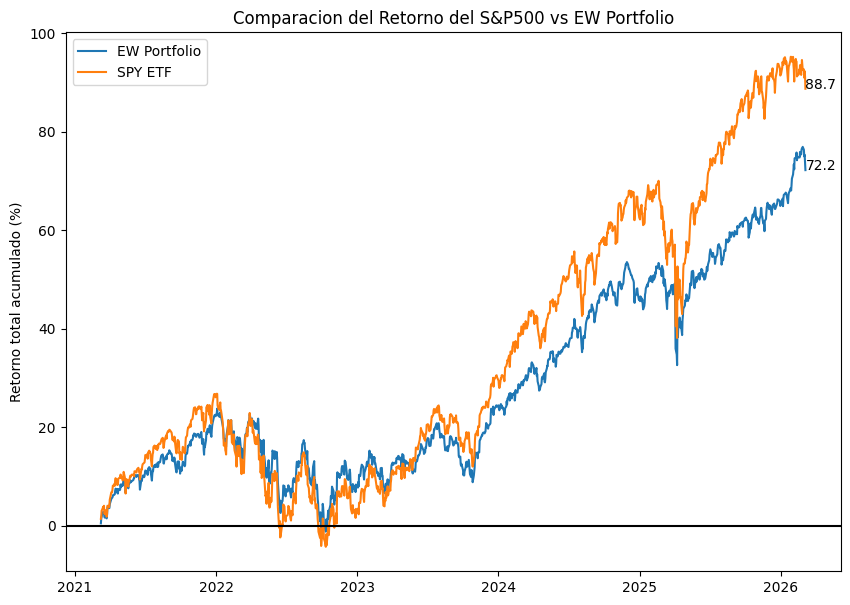

In [ ]:
# Realizamos el grafico del retorno acumulado del EW Portfolio (all tickers) vs el retorno acumulado del SPY (ETF sigue el S&P500)
plt.figure(figsize=(10, 7))

# Graficar portafolio
plt.plot(df_retornos['Port_returns_cumprod'] * 100, label='EW Portfolio')
plt.text(df_retornos.index[-1], df_retornos['Port_returns_cumprod'].iloc[-1] * 100, round(df_retornos['Port_returns_cumprod'].iloc[-1] * 100, 1))

# Graficar SPY
plt.plot(df_retornos['SPY_returns_cumprod'] * 100, label='SPY ETF')
plt.text(df_retornos.index[-1], df_retornos['SPY_returns_cumprod'].iloc[-1] * 100, round(df_retornos['SPY_returns_cumprod'].iloc[-1] * 100, 1))

# Configuración de la gráfica
plt.axhline(y=0, color='black')
plt.title('Comparacion del Retorno del S&P500 vs EW Portfolio')
plt.legend()
plt.ylabel('Retorno total acumulado (%)')
plt.show()

In [ ]:
y = df.resample('ME').last().pct_change().dropna()
y

Ticker,AAPL,BAC,IEF,KO,PG,SPY,VZ,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Date,,,,,,,,,,,,,,,,,,
2021-04-30,0.076218,0.047557,0.010013,0.024094,-0.008538,0.052910,0.004501,0.053807,0.064512,0.006727,0.064905,0.035348,0.051878,0.018592,0.083059,0.041849,0.039318,0.064557
2021-05-31,-0.050497,0.045892,0.004249,0.024268,0.010718,0.006566,-0.022495,0.050819,0.009481,0.057097,0.047711,0.031296,-0.009306,0.017678,0.011457,-0.023381,0.018709,-0.033982
2021-06-30,0.099109,-0.023270,0.010226,-0.013968,0.000593,0.022428,-0.008143,-0.052632,0.029516,0.042339,-0.030394,-0.022795,0.068863,-0.005445,0.031365,-0.022083,0.022989,0.034569
2021-07-31,0.064983,-0.069610,0.019902,0.053964,0.060732,0.024412,0.006722,0.020775,0.017661,-0.083163,-0.004633,0.009375,0.038873,0.022010,0.046244,0.043334,0.049226,0.010529
2021-08-31,0.042489,0.088373,-0.003945,-0.012625,0.001125,0.029760,-0.013984,0.018924,0.039078,-0.020044,0.051479,0.011126,0.035593,0.010488,0.028029,0.038957,0.023155,0.017846
2021-09-30,-0.068037,0.021977,-0.015970,-0.061161,-0.018189,-0.046605,-0.018000,-0.071886,-0.062753,0.089315,-0.018425,-0.060798,-0.058399,-0.041392,-0.062521,-0.060932,-0.055184,-0.021408
2021-10-31,0.058657,0.125560,-0.004429,0.074328,0.029159,0.070164,-0.007234,0.075971,0.002372,0.103283,0.072742,0.067968,0.081770,0.035009,0.075816,0.047433,0.051217,0.120925
2021-11-30,0.105082,-0.069276,0.010921,-0.062325,0.011120,-0.008035,-0.051330,-0.005522,-0.061395,-0.050113,-0.057129,-0.035602,0.044512,-0.013474,-0.008992,-0.017038,-0.030563,0.016356
2021-12-31,0.074229,0.005265,-0.005240,0.128885,0.131415,0.046248,0.033618,0.075832,0.032769,0.029834,0.033643,0.053976,0.032473,0.104547,0.102631,0.096893,0.090198,0.001497


In [ ]:
y.describe()

Ticker,AAPL,BAC,IEF,KO,PG,SPY,VZ,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,0.015338,0.008744,-0.000209,0.009811,0.005489,0.010889,0.004615,0.007139,0.010063,0.019621,0.009280,0.011643,0.014570,0.006606,0.005531,0.009871,0.006623,0.007773
std,0.070255,0.076669,0.021773,0.047131,0.051256,0.043603,0.058347,0.057188,0.052696,0.073244,0.051256,0.051107,0.060066,0.037752,0.055402,0.047634,0.041891,0.063807
min,-0.122272,-0.160773,-0.047350,-0.091150,-0.088758,-0.092446,-0.098105,-0.138563,-0.141320,-0.170735,-0.108609,-0.104309,-0.119671,-0.081328,-0.131713,-0.112810,-0.068564,-0.119568
25%,-0.042626,-0.042618,-0.014422,-0.021378,-0.027855,-0.017149,-0.027778,-0.033689,-0.015783,-0.013693,-0.025037,-0.024180,-0.017413,-0.016444,-0.033580,-0.021077,-0.029835,-0.034379
50%,0.018267,0.010507,0.002073,0.011314,0.000859,0.018247,0.002124,0.013322,0.017988,0.019531,0.007428,0.007783,0.012398,0.010886,0.010934,0.016282,0.016091,0.010810
75%,0.062607,0.053585,0.012492,0.035358,0.044004,0.039607,0.038097,0.052350,0.044064,0.050794,0.047797,0.045444,0.061216,0.028912,0.042886,0.043144,0.035589,0.035121
max,0.188634,0.193377,0.045544,0.128885,0.131415,0.092087,0.142285,0.117036,0.147739,0.249653,0.119236,0.138942,0.134519,0.104547,0.124774,0.103584,0.096111,0.184391


Calculando la matriz de correlaciones

In [ ]:
cm=y.corr()
cm

Ticker,AAPL,BAC,IEF,KO,PG,SPY,VZ,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Ticker,,,,,,,,,,,,,,,,,,
AAPL,1.000000,0.363875,0.494583,0.234023,0.185814,0.692012,0.024799,0.388681,0.555172,0.115049,0.373158,0.435934,0.738272,0.364853,0.596990,0.382680,0.457424,0.674953
BAC,0.363875,1.000000,0.302074,0.144789,0.122515,0.714422,0.149252,0.576493,0.583947,0.508733,0.905666,0.667731,0.526832,0.346399,0.497014,0.344816,0.399024,0.573752
IEF,0.494583,0.302074,1.000000,0.432928,0.241263,0.565452,0.483954,0.471686,0.588422,0.048994,0.397614,0.461238,0.524298,0.449648,0.653492,0.452503,0.500135,0.446773
KO,0.234023,0.144789,0.432928,1.000000,0.714601,0.322221,0.424034,0.528296,0.145638,0.293015,0.275189,0.456506,0.117597,0.852420,0.539478,0.572498,0.634684,0.035304
PG,0.185814,0.122515,0.241263,0.714601,1.000000,0.312842,0.430074,0.474098,0.191825,0.238909,0.233305,0.441934,0.155021,0.812400,0.416045,0.477738,0.456391,0.082947
SPY,0.692012,0.714422,0.565452,0.322221,0.312842,1.000000,0.214187,0.756247,0.846160,0.335715,0.780967,0.862832,0.900438,0.556812,0.797909,0.598059,0.641611,0.853599
VZ,0.024799,0.149252,0.483954,0.424034,0.430074,0.214187,1.000000,0.367966,0.324612,0.286174,0.276150,0.301985,0.076258,0.427153,0.344745,0.371149,0.292449,0.014060
XLB,0.388681,0.576493,0.471686,0.528296,0.474098,0.756247,0.367966,1.000000,0.600330,0.496206,0.732355,0.875192,0.489158,0.746255,0.823714,0.674325,0.686792,0.599926
XLC,0.555172,0.583947,0.588422,0.145638,0.191825,0.846160,0.324612,0.600330,1.000000,0.180855,0.663893,0.645564,0.787953,0.367766,0.650267,0.455166,0.453634,0.729810


Text(0.5, 1.0, 'Matriz de correlaciones')

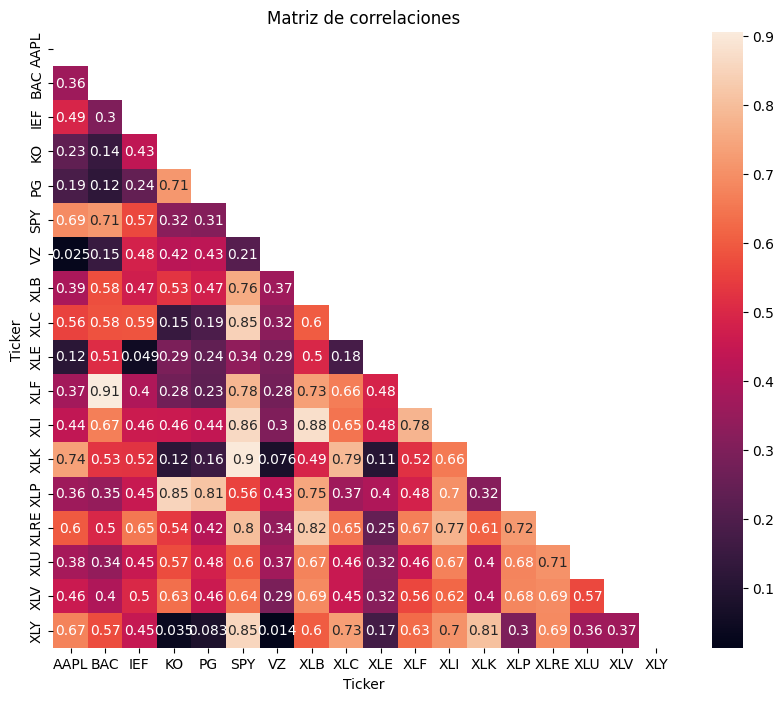

In [ ]:
# Mostramos la matriz de correlaciones con un heatmap
plt.figure(figsize=(10,8))
mask = np.triu(np.ones_like(cm, dtype=bool))
heatmap = sns.heatmap(cm, mask=mask, annot=True)
heatmap.set_title('Matriz de correlaciones')

Instalamos e importamos la libreria riskfolio lib

In [ ]:
%pip install riskfolio-lib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.9/319.9 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.2/310.2 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 420.7/420.7 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.7/318.7 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 39.9 MB/s eta 0:00:00


In [ ]:
import riskfolio as rp

<Axes: >

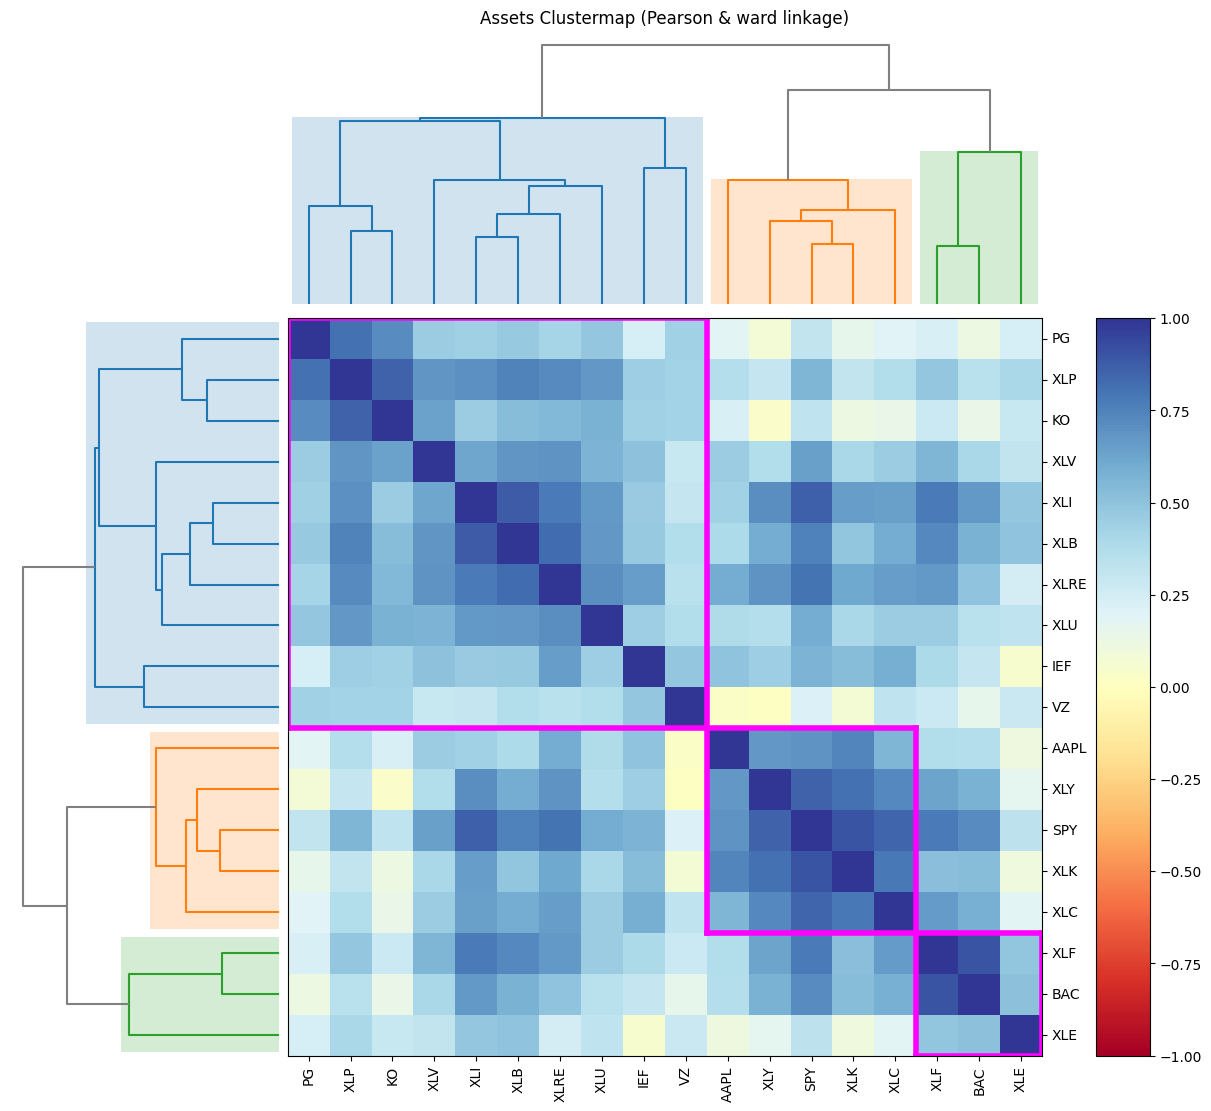

In [ ]:
#USAMOS CLUSTERING
rp.plot_clusters(y)

### Lectura del clustering

El dendrograma agrupa los activos en tres bloques con alta correlacion interna, casi
todos ligados al S&P 500. Esto anticipa el resultado de la optimizacion: como la
correlacion entre la mayoria de activos es alta, el beneficio de diversificacion
dentro de la renta variable es limitado, y el optimizador va a concentrar peso en
los pocos activos que se comportan distinto (renta fija, servicios publicos).

Correr el clustering antes de optimizar evita interpretar como hallazgo lo que en
realidad es estructura de correlaciones conocida.

Optimizacion de Portafolios: Modelo Clasico M/V con funcion objetivo maximizar el ratio de Sharpe


In [ ]:
# Construyendo el objeto rp denominandolo port con el modulo Portfolio
port = rp.Portfolio(returns=y)

method_mu = 'hist'
method_cov = 'hist'

port.assets_stats(method_mu=method_mu, method_cov=method_cov)

# Parametrizacion del modelo
port.alpha = 0.05
model = 'Classic' # Modelo calculado con datos historicos
rm = 'MV' # Utilizando la matriz de varianzas y covarianzas historica
obj = 'Sharpe' # Maximizando el ratio de Sharpe, otras opciones son 'MinRisk' y 'MaxRet'
hist = True
rf = 0 # La tasa libre de riesgo
l = 0 # lambda es un factor de aversion al riesgo, que se utiliza para modelar funciones de utilidad

w = port.optimization(model=model, rm=rm, obj=obj, hist=hist, rf=rf, l=l)

In [ ]:
display(w)

,weights
AAPL,5.057899e-02
BAC,2.197688e-09
IEF,5.004361e-09
KO,2.817717e-01
PG,6.302961e-09
SPY,1.002628e-08
VZ,7.417127e-09
XLB,2.419370e-09
XLC,1.445626e-08
XLE,3.238589e-01


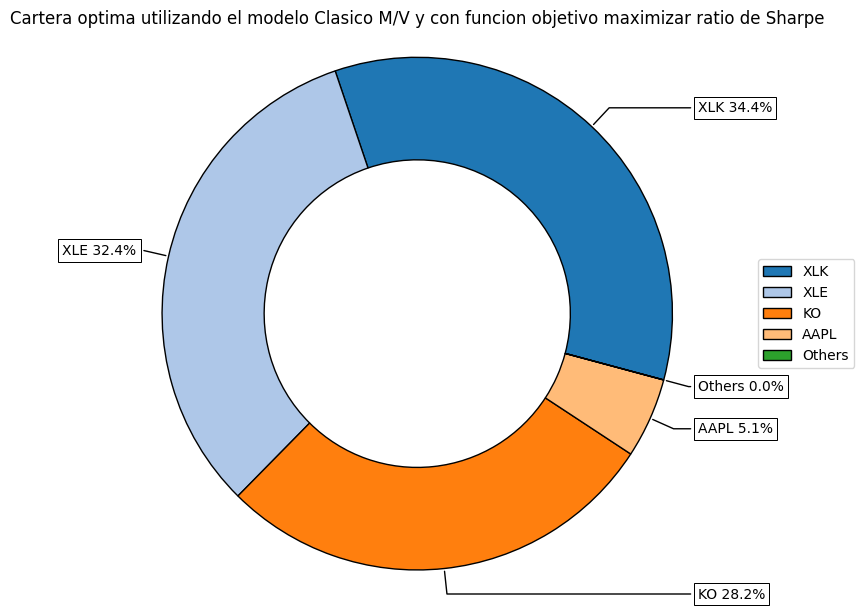

In [ ]:
# Graficamos el portafolio maximizando el ratio de Sharpe
ax = rp.plot_pie(w=w, title='Cartera optima utilizando el modelo Clasico M/V y con funcion objetivo maximizar ratio de Sharpe')

In [ ]:
points = 50
frontier = port.efficient_frontier(model=model, rm=rm, points=points, hist=hist, rf=rf)
display(frontier.T.head(20))

,AAPL,BAC,IEF,KO,PG,SPY,VZ,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
0,1.875977e-10,2.775683e-10,8.843073e-01,5.132850e-10,5.612761e-02,4.083199e-10,2.288976e-10,2.011479e-10,2.484078e-10,0.059565,5.880121e-10,3.040822e-10,2.554048e-10,1.349911e-09,1.478904e-10,5.233751e-10,7.280231e-10,3.275097e-10
1,3.579577e-08,8.118965e-09,7.676873e-01,1.094098e-02,6.878176e-02,7.214105e-08,1.046067e-08,6.910161e-09,2.442915e-08,0.126038,3.284640e-08,1.869380e-08,2.655164e-02,1.183578e-07,6.066750e-09,1.574108e-07,5.735365e-08,1.934812e-08
2,1.622189e-09,2.842914e-10,6.989844e-01,5.305475e-02,5.056800e-02,2.902308e-09,4.206252e-10,2.489008e-10,1.078745e-09,0.138940,1.401125e-09,7.067834e-10,5.845330e-02,4.244226e-09,2.211245e-10,4.366404e-08,2.380873e-09,6.911865e-10
3,1.491473e-08,2.045907e-09,6.390678e-01,8.885394e-02,3.465315e-02,1.888938e-08,3.743014e-09,1.863312e-09,9.524555e-09,0.149972,9.666461e-09,5.224060e-09,8.575569e-02,2.428298e-08,1.691219e-09,1.697168e-03,1.484399e-08,4.819891e-09
4,5.489885e-08,2.431977e-09,5.845115e-01,1.209226e-01,2.018483e-02,1.142167e-08,6.943346e-09,2.487523e-09,8.387932e-09,0.159893,4.858754e-09,5.637007e-09,1.103227e-01,1.785780e-08,2.460044e-09,4.165698e-03,7.924749e-09,5.256162e-09
5,7.369986e-08,6.329238e-09,5.337844e-01,1.509016e-01,6.603054e-03,5.355567e-08,1.718698e-08,6.054876e-09,4.238371e-08,0.169121,3.016745e-08,1.665643e-08,1.331952e-01,6.143390e-08,5.659757e-09,6.394328e-03,4.176152e-08,1.446232e-08
6,1.203378e-07,9.637825e-09,4.835634e-01,1.751932e-01,8.383090e-08,7.415040e-08,3.030304e-08,9.372625e-09,7.061704e-08,0.178032,4.290339e-08,2.589815e-08,1.552628e-01,7.537176e-08,8.787061e-09,7.948060e-03,5.739396e-08,2.112415e-08
7,2.509074e-08,4.041556e-09,4.334925e-01,1.942108e-01,3.312441e-08,2.469136e-08,1.494516e-08,4.075087e-09,2.818255e-08,0.186680,1.319536e-08,1.013822e-08,1.766905e-01,2.324906e-08,4.037455e-09,8.926113e-03,1.909598e-08,8.304957e-09
8,1.056061e-08,9.205408e-10,3.855336e-01,2.125045e-01,8.603744e-09,6.689374e-09,3.674649e-09,9.132283e-10,8.759682e-09,0.195012,4.095656e-09,2.400767e-09,1.972765e-01,5.862922e-09,8.933743e-10,9.673566e-03,5.222593e-09,1.971231e-09
9,1.155117e-07,1.372834e-09,3.391873e-01,2.301497e-01,1.023622e-08,9.755683e-09,6.154564e-09,1.369948e-09,1.496715e-08,0.203040,6.061510e-09,3.548927e-09,2.171414e-01,8.195139e-09,1.364194e-09,1.048109e-02,7.826955e-09,2.964072e-09


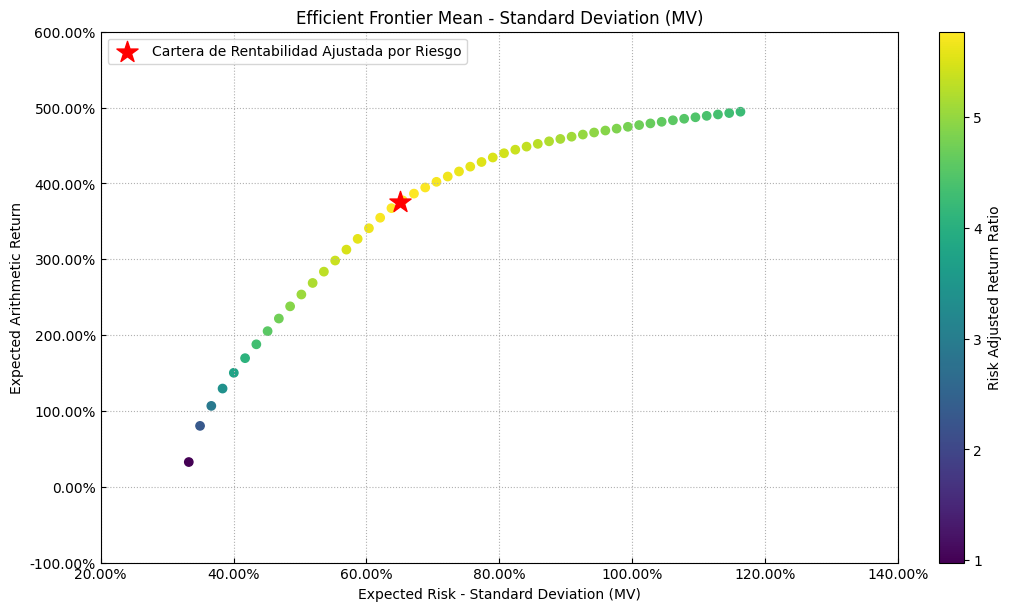

In [ ]:
ax = rp.plot_frontier(w_frontier=frontier, mu=port.mu, cov=port.cov, returns=port.returns, w=w, label='Cartera de Rentabilidad Ajustada por Riesgo')

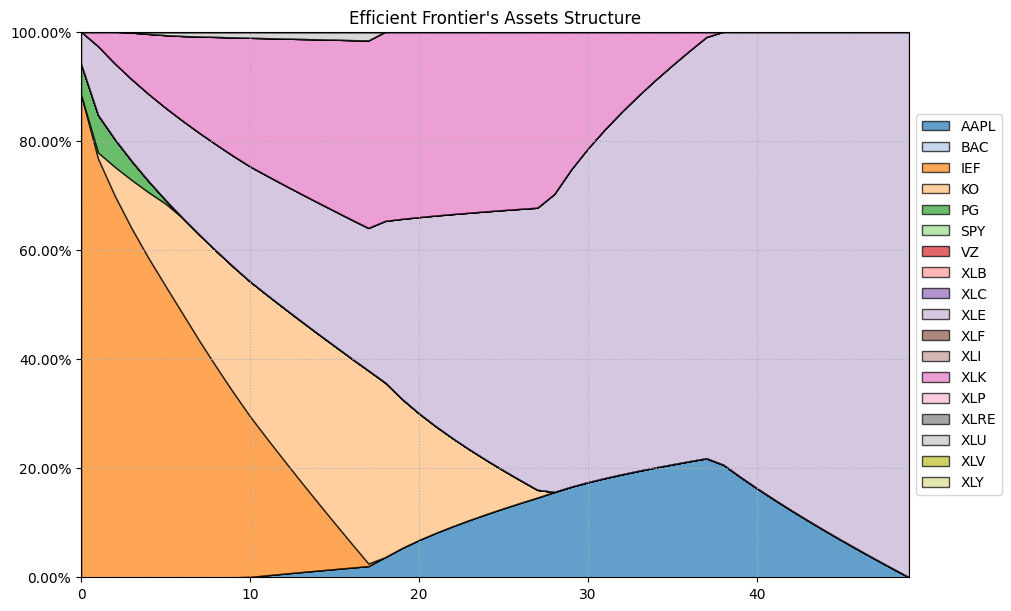

In [ ]:
# Graficamos la evolucion de la frontera eficiente
ax = rp.plot_frontier_area(w_frontier=frontier, cmap="tab20", height=6, width=10, ax=None)

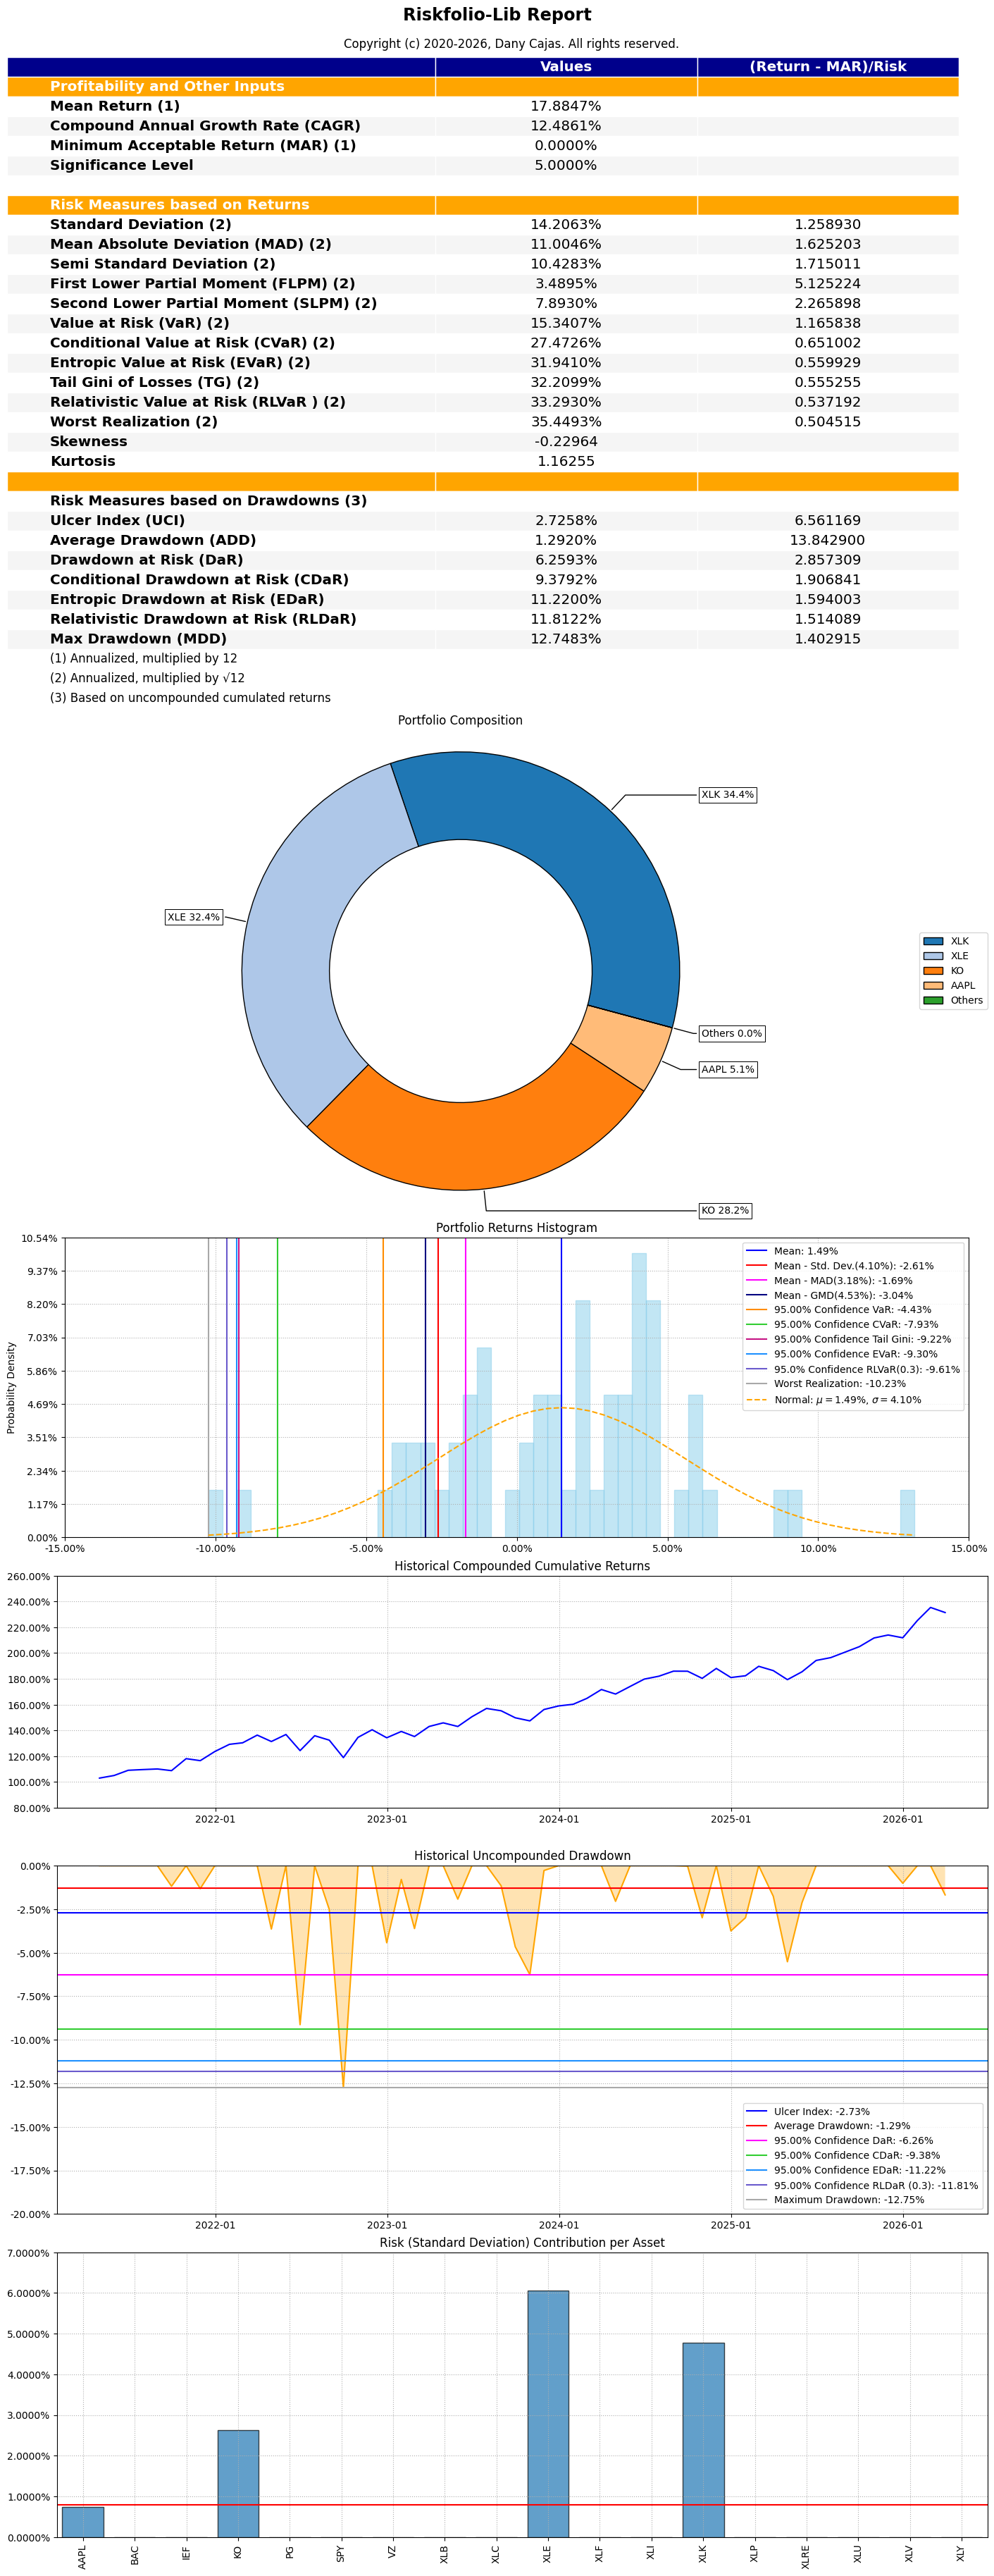

In [ ]:
ax = rp.jupyter_report(y, w, rm=rm, t_factor=12)

Optimizacion de Portafolios: Modelo Clasico M/V con funcion objetivo minimización del riesgo

In [ ]:
# Parametrizacion del modelo
port.alpha = 0.05
model = 'Classic' # Modelo calculado con datos historicos
rm = 'MV' # Utilizando la matriz de varianzas y covarianzas historica
obj = 'MinRisk' # Maximizando el ratio de Sharpe, otras opciones son 'MinRisk' y 'MaxRet'
hist = True
rf = 0 # La tasa libre de riesgo
l = 0 # lambda es un factor de aversion al riesgo, que se utiliza para modelar funciones de utilidad

w_min = port.optimization(model=model, rm=rm, obj=obj, hist=hist, rf=rf, l=l)
display(w_min)

,weights
AAPL,1.875977e-10
BAC,2.775683e-10
IEF,8.843073e-01
KO,5.132850e-10
PG,5.612761e-02
SPY,4.083199e-10
VZ,2.288976e-10
XLB,2.011479e-10
XLC,2.484078e-10
XLE,5.956508e-02


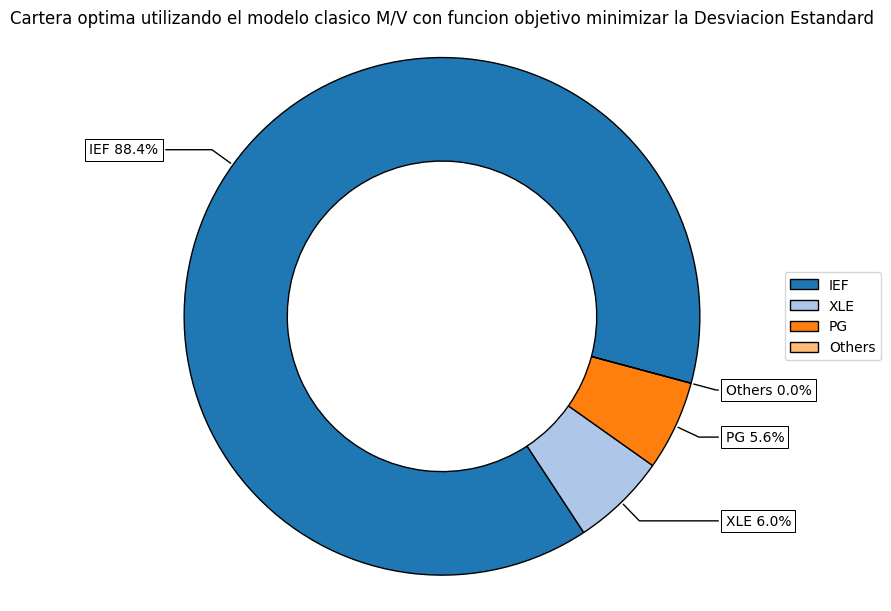

In [ ]:
# Graficamos el portafolio optimo minimizando el riesgo total
ax = rp.plot_pie(w=w_min, title='Cartera optima utilizando el modelo clasico M/V con funcion objetivo minimizar la Desviacion Estandard')

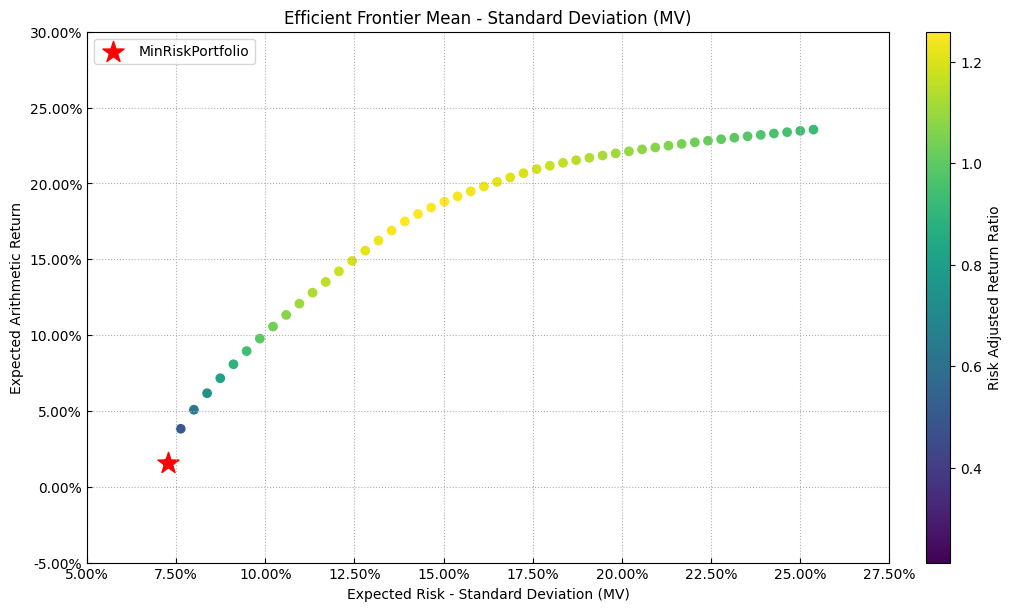

In [ ]:
ax = rp.plot_frontier(w_frontier=frontier, mu=port.mu, cov=port.cov, returns=port.returns, w=w_min, label='MinRiskPortfolio', t_factor=12)

### Lectura de la frontera con minimizacion de riesgo

Los activos marcados en la frontera son los que no se penalizan entre si: su
correlacion cruzada es lo bastante baja como para que agregarlos mejore el retorno
ajustado por riesgo del conjunto en lugar de solo diluirlo.

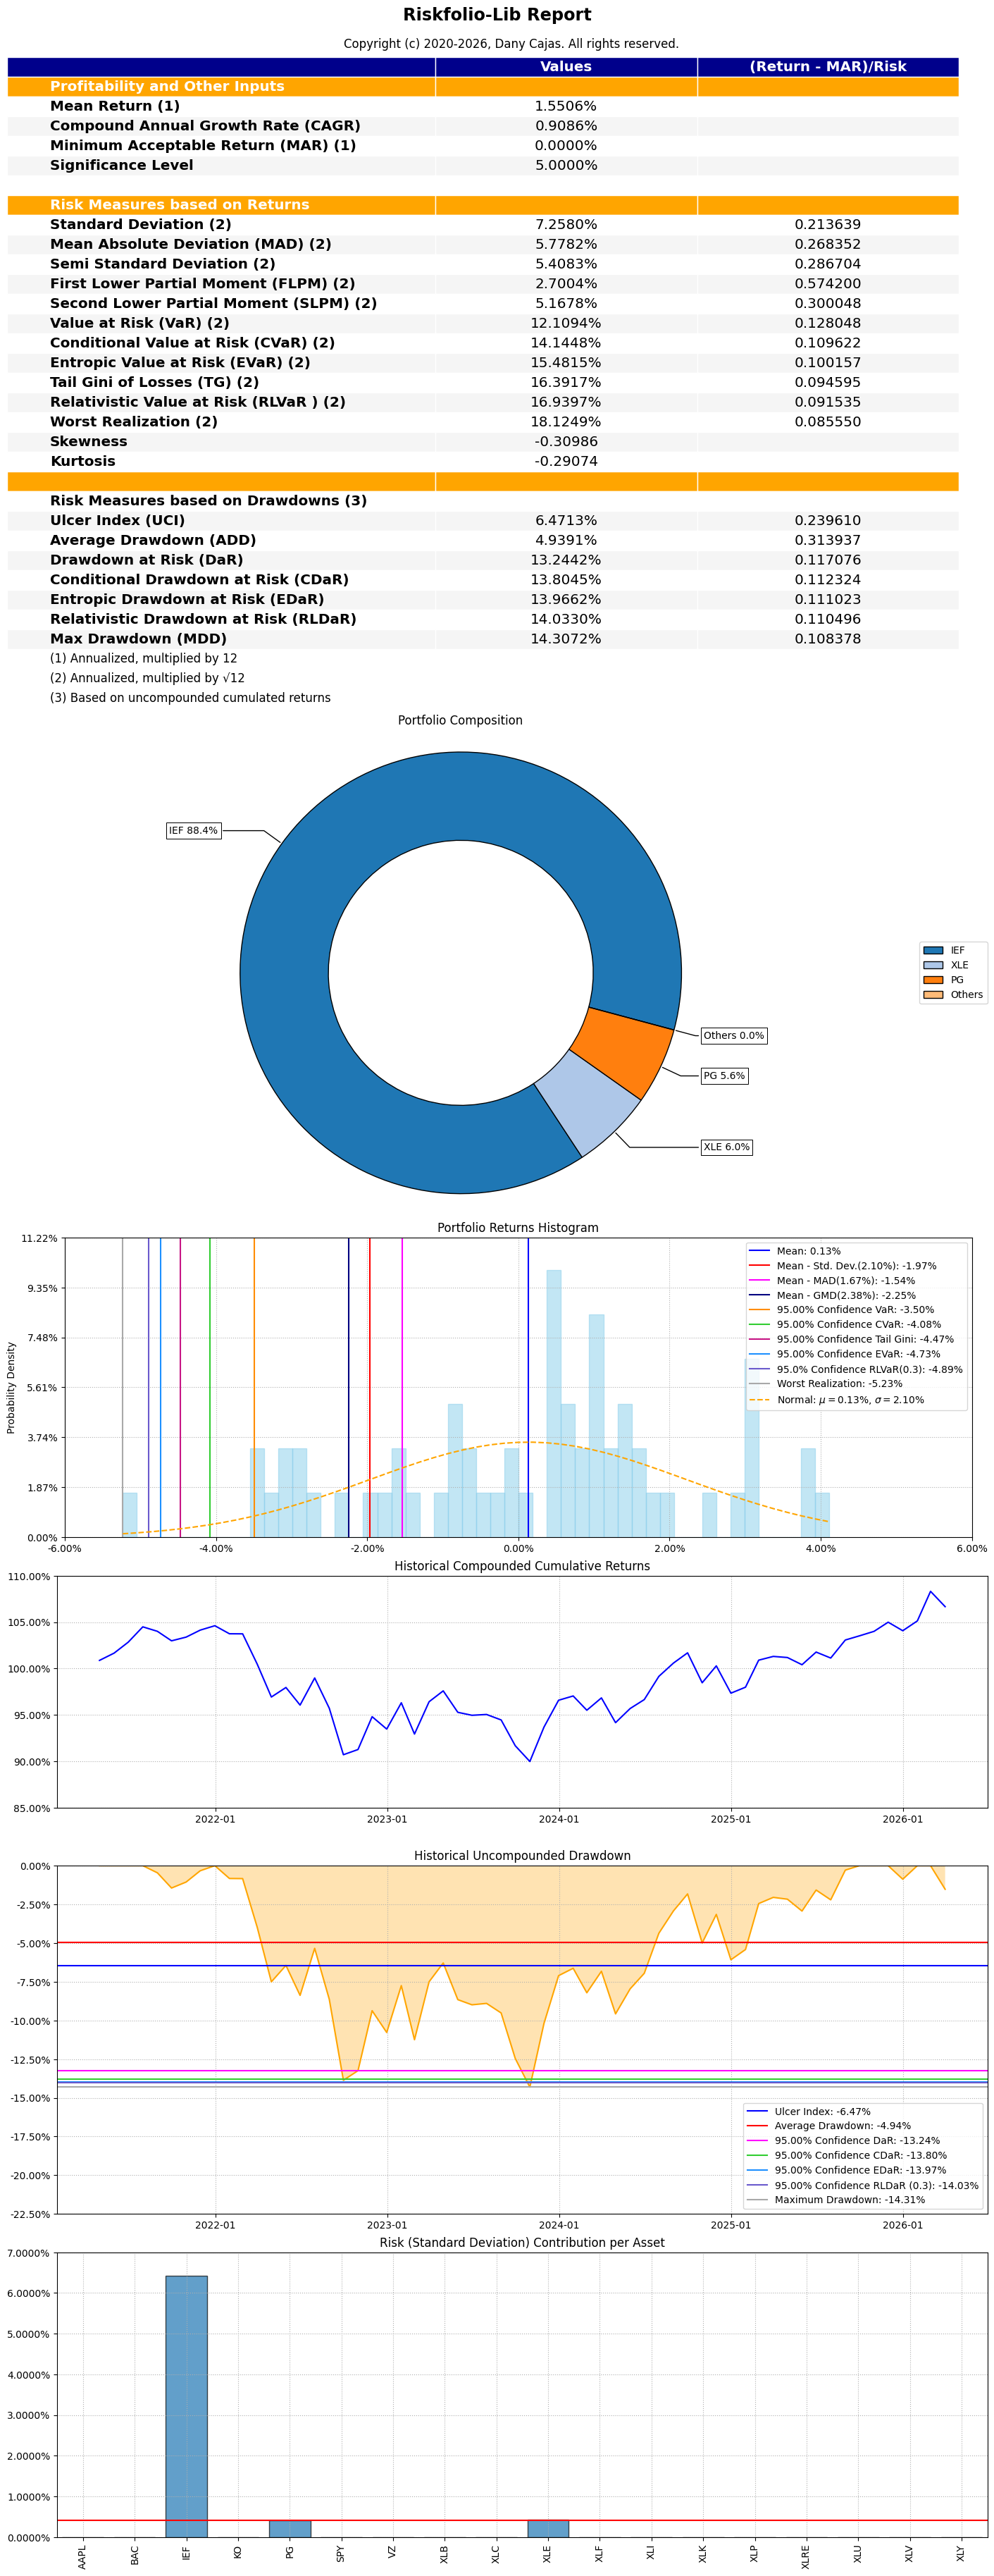

In [ ]:
ax=rp.jupyter_report(y,w_min,rm=rm,t_factor=12)
plt.show()

Optimizacion de Portafolios: Modelo Clasico M/V con funcion objetivo maximizacion del retorno

In [ ]:
# Parametrizacion del modelo
port.alpha=0.05
model='Classic' # Modelo calculado con datos historicos
rm='MV' # Utilizando la matriz de varianzas y covarianzas historica
obj='MaxRet' # Maximizando el ratio de Sharpe, otras opciones son 'MinRisk' y 'MaxRet'
hist=True
rf=0 # La tasa libre de riesgo
l=0 # lambda es un factor de aversion al riesgo, que se utiliza para modelar funciones de utilidad

In [ ]:
w_max=port.optimization(model=model,rm=rm,obj=obj,hist=hist,rf=rf,l=l)
display(w_max)

,weights
AAPL,2.494797e-10
BAC,7.416868e-11
IEF,3.152725e-11
KO,5.537943e-11
PG,4.418098e-11
SPY,8.105205e-11
VZ,4.099136e-11
XLB,5.559693e-11
XLC,7.042236e-11
XLE,1.000000e+00


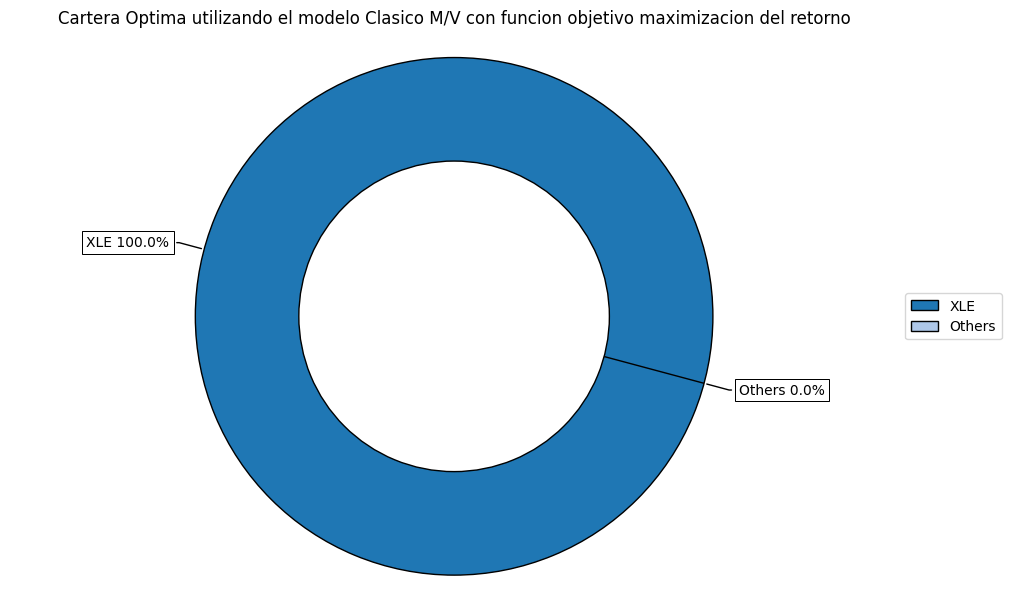

In [ ]:
# Graficamos el portafolio optimo maximizando el retorno del portafolio
ax=rp.plot_pie(w=w_max,title='Cartera Optima utilizando el modelo Clasico M/V con funcion objetivo maximizacion del retorno',nrow=25,height=6,width=10)

In [ ]:
points=50
frontier=port.efficient_frontier(model=model, rm=rm,points=points,hist=hist,rf=rf)
display(frontier.T.head(10))

,AAPL,BAC,IEF,KO,PG,SPY,VZ,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
0,1.875977e-10,2.775683e-10,0.884307,5.132850e-10,5.612761e-02,4.083199e-10,2.288976e-10,2.011479e-10,2.484078e-10,0.059565,5.880121e-10,3.040822e-10,2.554048e-10,1.349911e-09,1.478904e-10,5.233751e-10,7.280231e-10,3.275097e-10
1,3.579577e-08,8.118965e-09,0.767687,1.094098e-02,6.878176e-02,7.214105e-08,1.046067e-08,6.910161e-09,2.442915e-08,0.126038,3.284640e-08,1.869380e-08,2.655164e-02,1.183578e-07,6.066750e-09,1.574108e-07,5.735365e-08,1.934812e-08
2,1.622189e-09,2.842914e-10,0.698984,5.305475e-02,5.056800e-02,2.902308e-09,4.206252e-10,2.489008e-10,1.078745e-09,0.138940,1.401125e-09,7.067834e-10,5.845330e-02,4.244226e-09,2.211245e-10,4.366404e-08,2.380873e-09,6.911865e-10
3,1.491473e-08,2.045907e-09,0.639068,8.885394e-02,3.465315e-02,1.888938e-08,3.743014e-09,1.863312e-09,9.524555e-09,0.149972,9.666461e-09,5.224060e-09,8.575569e-02,2.428298e-08,1.691219e-09,1.697168e-03,1.484399e-08,4.819891e-09
4,5.489885e-08,2.431977e-09,0.584512,1.209226e-01,2.018483e-02,1.142167e-08,6.943346e-09,2.487523e-09,8.387932e-09,0.159893,4.858754e-09,5.637007e-09,1.103227e-01,1.785780e-08,2.460044e-09,4.165698e-03,7.924749e-09,5.256162e-09
5,7.369986e-08,6.329238e-09,0.533784,1.509016e-01,6.603054e-03,5.355567e-08,1.718698e-08,6.054876e-09,4.238371e-08,0.169121,3.016745e-08,1.665643e-08,1.331952e-01,6.143390e-08,5.659757e-09,6.394328e-03,4.176152e-08,1.446232e-08
6,1.203378e-07,9.637825e-09,0.483563,1.751932e-01,8.383090e-08,7.415040e-08,3.030304e-08,9.372625e-09,7.061704e-08,0.178032,4.290339e-08,2.589815e-08,1.552628e-01,7.537176e-08,8.787061e-09,7.948060e-03,5.739396e-08,2.112415e-08
7,2.509074e-08,4.041556e-09,0.433492,1.942108e-01,3.312441e-08,2.469136e-08,1.494516e-08,4.075087e-09,2.818255e-08,0.186680,1.319536e-08,1.013822e-08,1.766905e-01,2.324906e-08,4.037455e-09,8.926113e-03,1.909598e-08,8.304957e-09
8,1.056061e-08,9.205408e-10,0.385534,2.125045e-01,8.603744e-09,6.689374e-09,3.674649e-09,9.132283e-10,8.759682e-09,0.195012,4.095656e-09,2.400767e-09,1.972765e-01,5.862922e-09,8.933743e-10,9.673566e-03,5.222593e-09,1.971231e-09
9,1.155117e-07,1.372834e-09,0.339187,2.301497e-01,1.023622e-08,9.755683e-09,6.154564e-09,1.369948e-09,1.496715e-08,0.203040,6.061510e-09,3.548927e-09,2.171414e-01,8.195139e-09,1.364194e-09,1.048109e-02,7.826955e-09,2.964072e-09


In [ ]:
ax=rp.plot_frontier(w_frontier=frontier,mu=port.mu,cov=port.cov,returns=port.returns,w=w_max,label='Max Ret Portfolio',t_factor=12)

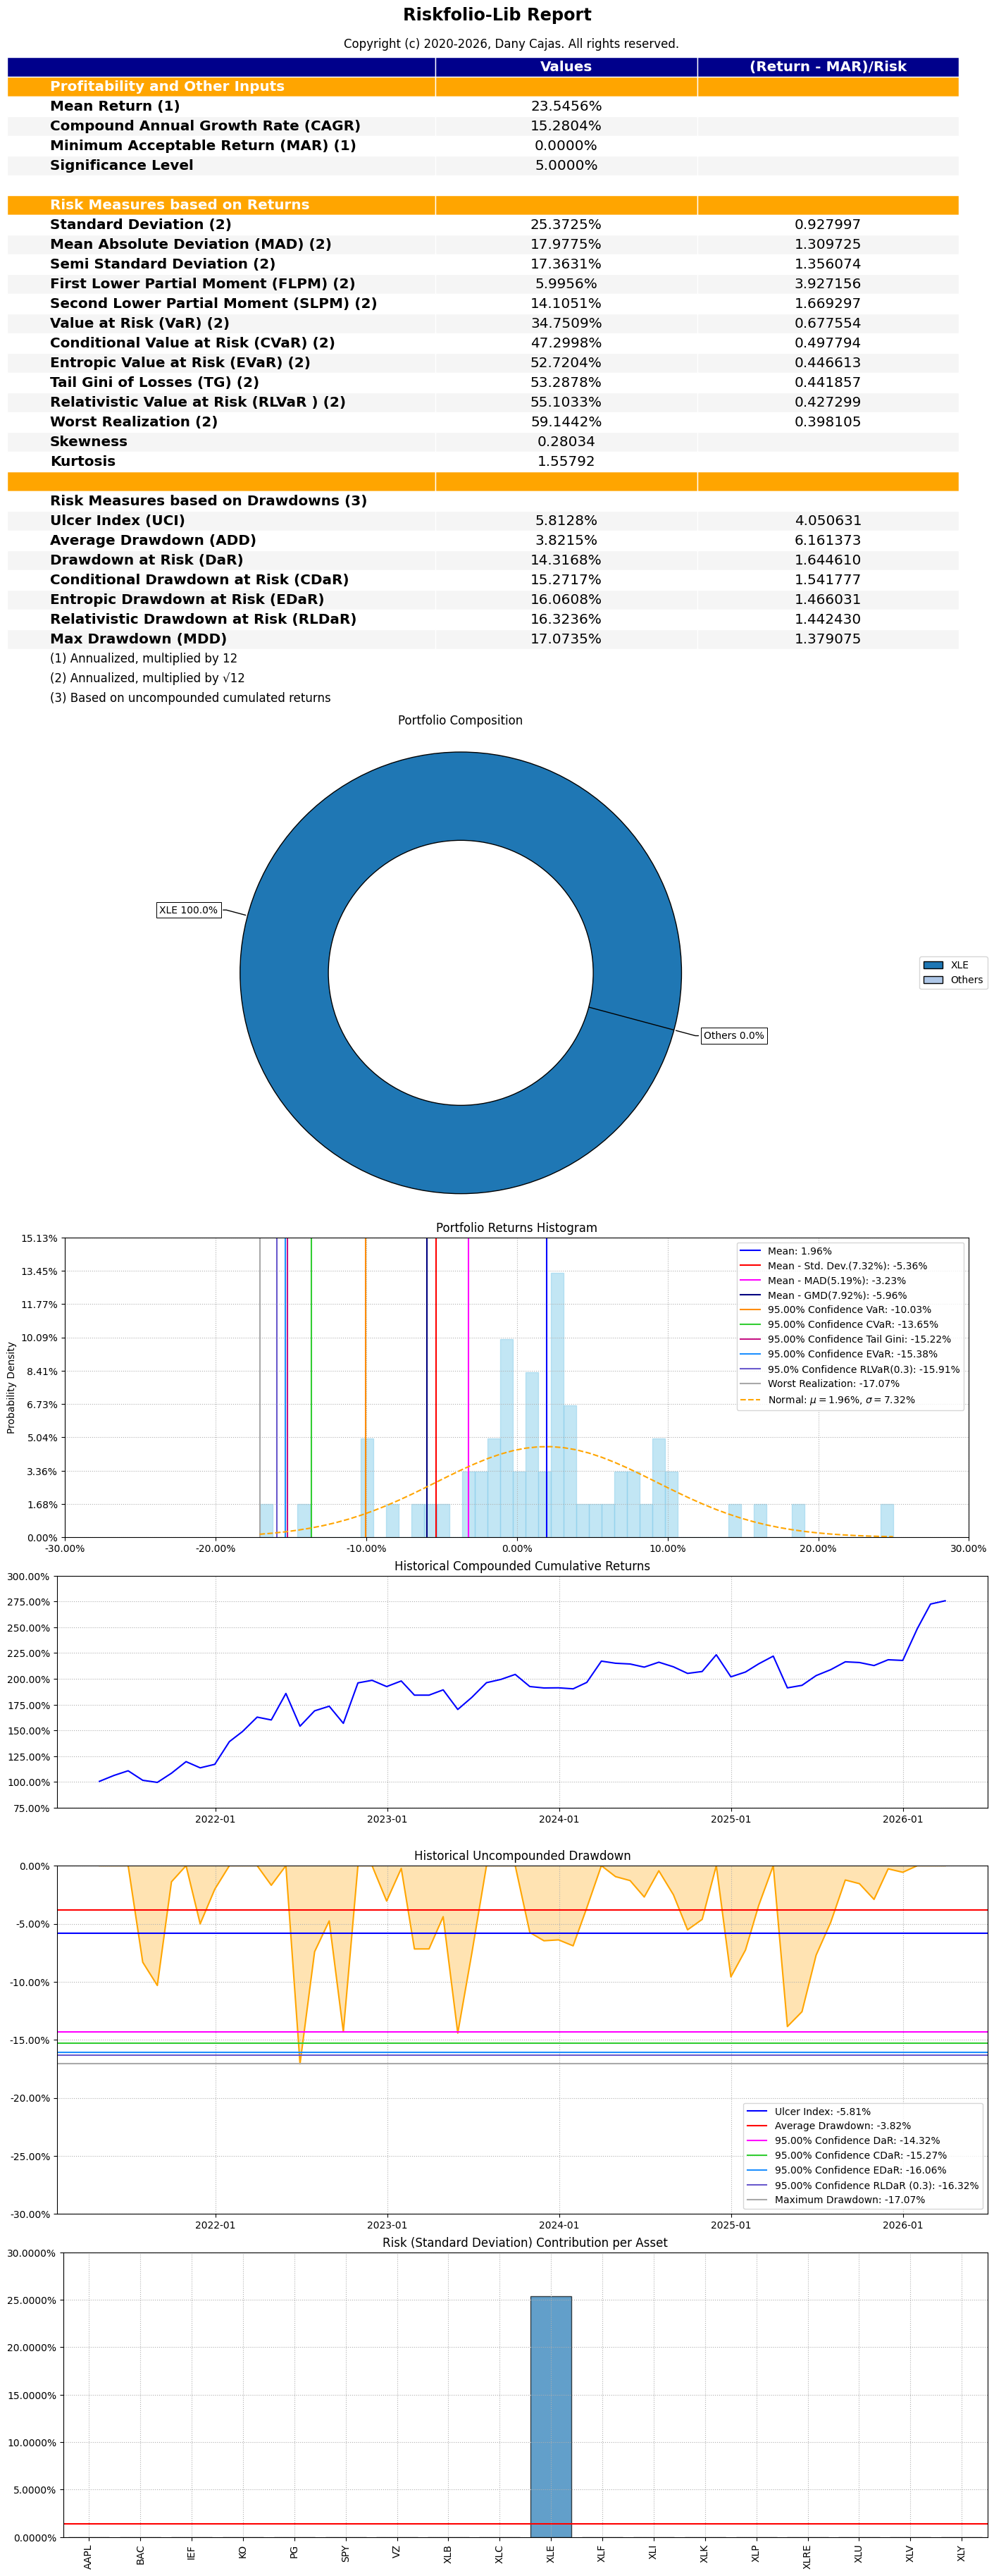

In [ ]:
ax=rp.jupyter_report(y,w_max,rm=rm,t_factor=12)
plt.show()

Comparando los pesos de los portafolios segun funcion objetivo

In [ ]:
w=w.rename(columns={'weights':'w_sharpe_ratio'})
w

,w_sharpe_ratio
AAPL,5.057899e-02
BAC,2.197688e-09
IEF,5.004361e-09
KO,2.817717e-01
PG,6.302961e-09
SPY,1.002628e-08
VZ,7.417127e-09
XLB,2.419370e-09
XLC,1.445626e-08
XLE,3.238589e-01


In [ ]:
w_portfolios=w
w_portfolios['w_min_risk']=w_min
w_portfolios['w_max_return']=w_max
w_portfolios

,w_sharpe_ratio,w_min_risk,w_max_return
AAPL,5.057899e-02,1.875977e-10,2.494797e-10
BAC,2.197688e-09,2.775683e-10,7.416868e-11
IEF,5.004361e-09,8.843073e-01,3.152725e-11
KO,2.817717e-01,5.132850e-10,5.537943e-11
PG,6.302961e-09,5.612761e-02,4.418098e-11
SPY,1.002628e-08,4.083199e-10,8.105205e-11
VZ,7.417127e-09,2.288976e-10,4.099136e-11
XLB,2.419370e-09,2.011479e-10,5.559693e-11
XLC,1.445626e-08,2.484078e-10,7.042236e-11
XLE,3.238589e-01,5.956508e-02,1.000000e+00


In [ ]:
# Comparacion entre los pesos de los portafolios M/V segun funcion objetivo: Ratio de Sharpe, MinRisk y MaxRet
w_portfolios.style.format("{:.2%}").background_gradient(cmap='YlGn')

,w_sharpe_ratio,w_min_risk,w_max_return
AAPL,5.06%,0.00%,0.00%
BAC,0.00%,0.00%,0.00%
IEF,0.00%,88.43%,0.00%
KO,28.18%,0.00%,0.00%
PG,0.00%,5.61%,0.00%
SPY,0.00%,0.00%,0.00%
VZ,0.00%,0.00%,0.00%
XLB,0.00%,0.00%,0.00%
XLC,0.00%,0.00%,0.00%
XLE,32.39%,5.96%,100.00%


Obteniendo la estructura de la cartera bajo el modelo de Risk Parity

In [ ]:
y

Ticker,AAPL,BAC,IEF,KO,PG,SPY,VZ,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Date,,,,,,,,,,,,,,,,,,
2021-04-30,0.076218,0.047557,0.010013,0.024094,-0.008538,0.052910,0.004501,0.053807,0.064512,0.006727,0.064905,0.035348,0.051878,0.018592,0.083059,0.041849,0.039318,0.064557
2021-05-31,-0.050497,0.045892,0.004249,0.024268,0.010718,0.006566,-0.022495,0.050819,0.009481,0.057097,0.047711,0.031296,-0.009306,0.017678,0.011457,-0.023381,0.018709,-0.033982
2021-06-30,0.099109,-0.023270,0.010226,-0.013968,0.000593,0.022428,-0.008143,-0.052632,0.029516,0.042339,-0.030394,-0.022795,0.068863,-0.005445,0.031365,-0.022083,0.022989,0.034569
2021-07-31,0.064983,-0.069610,0.019902,0.053964,0.060732,0.024412,0.006722,0.020775,0.017661,-0.083163,-0.004633,0.009375,0.038873,0.022010,0.046244,0.043334,0.049226,0.010529
2021-08-31,0.042489,0.088373,-0.003945,-0.012625,0.001125,0.029760,-0.013984,0.018924,0.039078,-0.020044,0.051479,0.011126,0.035593,0.010488,0.028029,0.038957,0.023155,0.017846
2021-09-30,-0.068037,0.021977,-0.015970,-0.061161,-0.018189,-0.046605,-0.018000,-0.071886,-0.062753,0.089315,-0.018425,-0.060798,-0.058399,-0.041392,-0.062521,-0.060932,-0.055184,-0.021408
2021-10-31,0.058657,0.125560,-0.004429,0.074328,0.029159,0.070164,-0.007234,0.075971,0.002372,0.103283,0.072742,0.067968,0.081770,0.035009,0.075816,0.047433,0.051217,0.120925
2021-11-30,0.105082,-0.069276,0.010921,-0.062325,0.011120,-0.008035,-0.051330,-0.005522,-0.061395,-0.050113,-0.057129,-0.035602,0.044512,-0.013474,-0.008992,-0.017038,-0.030563,0.016356
2021-12-31,0.074229,0.005265,-0.005240,0.128885,0.131415,0.046248,0.033618,0.075832,0.032769,0.029834,0.033643,0.053976,0.032473,0.104547,0.102631,0.096893,0.090198,0.001497


Estimacion del Portfolio Risk-Parity

In [ ]:
b=None # restricciones de la contribucion al riesgo

In [ ]:
w_rp=port.rp_optimization(model=model,rm=rm,rf=rf,b=b,hist=hist)

In [ ]:
display(w_rp.T)

,AAPL,BAC,IEF,KO,PG,SPY,VZ,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
weights,0.044011,0.037243,0.132369,0.065691,0.066139,0.048976,0.067142,0.038507,0.048663,0.052802,0.04764,0.042339,0.046146,0.063212,0.039508,0.054572,0.060748,0.04429


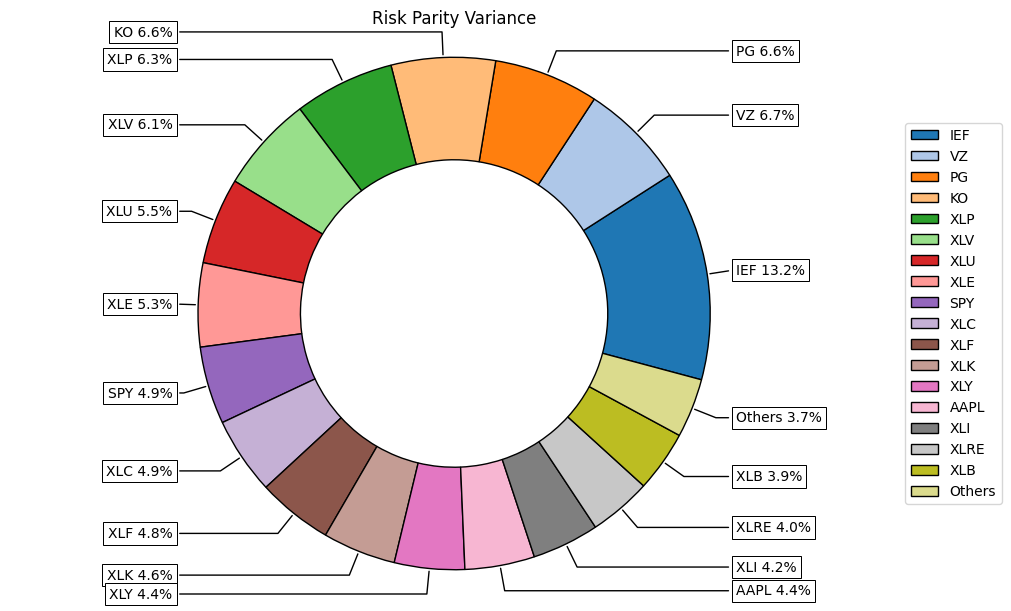

In [ ]:
# Mostrando la composicion del portafolio
ax=rp.plot_pie(w=w_rp,title='Risk Parity Variance', others=0.05,nrow=25,cmap="tab20",height=6,width=10,ax=None)

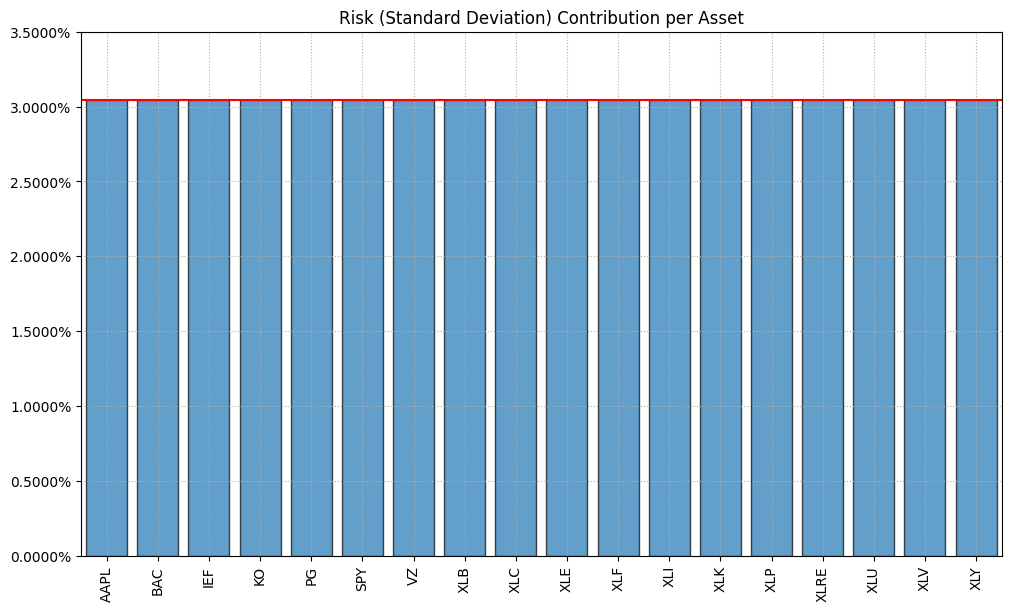

In [ ]:
# Mostrando la contribucion al riesgo del portafolio
ax=rp.plot_risk_con(w_rp,cov=port.cov,returns=port.returns,rm=rm,rf=rf,alpha=0.01,color="tab:blue")

Calculo de los pesos de All Weather Portafolio

In [ ]:
tickers_awp=['DBC','GLD','IEF','SPY','TLT']

In [ ]:
df_awp=yf.download(tickers_awp,period='5y',auto_adjust=False)['Adj Close']df_awp

[*********************100%***********************]  5 of 5 completed


Ticker,DBC,GLD,IEF,SPY,TLT
Date,,,,,
2021-03-08,14.905462,157.490005,99.957489,356.326599,117.746635
2021-03-09,14.905462,160.839996,100.431068,361.414032,119.378258
2021-03-10,15.001179,161.660004,100.641541,363.663727,119.617516
2021-03-11,15.227415,161.520004,100.606468,367.350922,118.754639
2021-03-12,15.157804,161.490005,99.878510,367.845673,116.234543
...,...,...,...,...,...
2026-03-02,25.809999,490.000000,97.120003,686.380005,89.610001
2026-03-03,25.910000,468.140015,97.010002,680.330017,89.430000
2026-03-04,26.139999,471.799988,96.809998,685.130005,89.150002


In [ ]:
y_awp=df_awp.pct_change()
y_awp=y_awp.dropna()
y_awp

Ticker,DBC,GLD,IEF,SPY,TLT
Date,,,,,
2021-03-09,0.000000,0.021271,0.004738,0.014277,0.013857
2021-03-10,0.006422,0.005098,0.002096,0.006225,0.002004
2021-03-11,0.015081,-0.000866,-0.000348,0.010139,-0.007214
2021-03-12,-0.004571,-0.000186,-0.007236,0.001347,-0.021221
2021-03-15,-0.003444,0.004397,0.001230,0.005964,0.005880
...,...,...,...,...,...
2026-03-02,0.028287,0.012920,-0.006008,0.000569,-0.010042
2026-03-03,0.003874,-0.044612,-0.001133,-0.008814,-0.002009
2026-03-04,0.008877,0.007818,-0.002062,0.007055,-0.003131


In [ ]:
port=rp.Portfolio(returns=y_awp)

In [ ]:
method_mu='hist'
method_cov='hist'

In [ ]:
port.assets_stats(method_mu=method_mu,method_cov=method_cov)

Estimacion del All Weather Portfolio siguiendo metodologia de Risk Parity


In [ ]:
b=None # restricciones de la contribucion al riesgo

In [ ]:
w_rp=port.rp_optimization(model=model,rm=rm,rf=rf,b=b,hist=hist)

In [ ]:
display(w.T)

,AAPL,BAC,IEF,KO,PG,SPY,VZ,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
w_sharpe_ratio,5.057899e-02,2.197688e-09,5.004361e-09,2.817717e-01,6.302961e-09,1.002628e-08,7.417127e-09,2.419370e-09,1.445626e-08,0.323859,6.418118e-09,6.448645e-09,3.437903e-01,6.673564e-09,2.448138e-09,3.067669e-08,6.620343e-09,3.554223e-09
w_min_risk,1.875977e-10,2.775683e-10,8.843073e-01,5.132850e-10,5.612761e-02,4.083199e-10,2.288976e-10,2.011479e-10,2.484078e-10,0.059565,5.880121e-10,3.040822e-10,2.554048e-10,1.349911e-09,1.478904e-10,5.233751e-10,7.280231e-10,3.275097e-10
w_max_return,2.494797e-10,7.416868e-11,3.152725e-11,5.537943e-11,4.418098e-11,8.105205e-11,4.099136e-11,5.559693e-11,7.042236e-11,1.000000,7.077381e-11,9.318312e-11,1.783013e-10,4.974474e-11,4.572705e-11,6.477859e-11,5.008898e-11,6.177803e-11


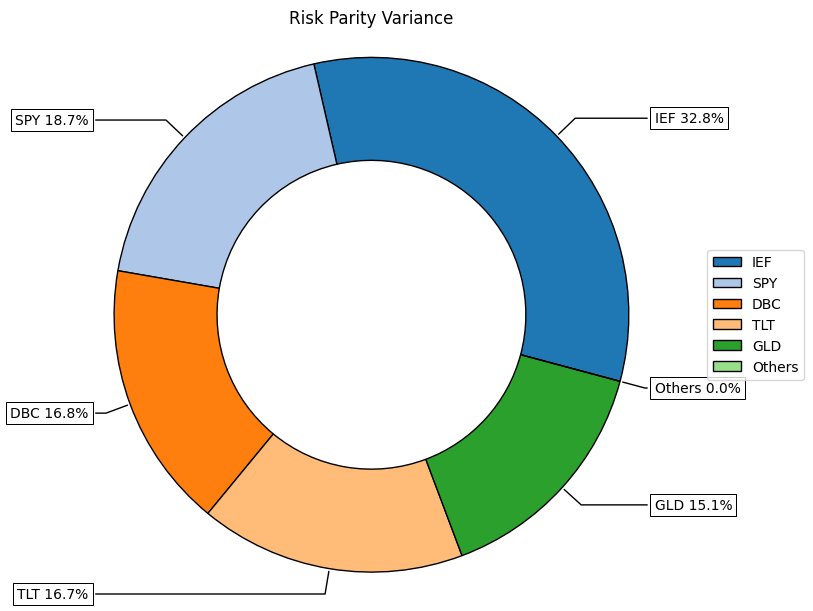

In [ ]:
ax=rp.plot_pie(w=w_rp,title='Risk Parity Variance',others=0.05)

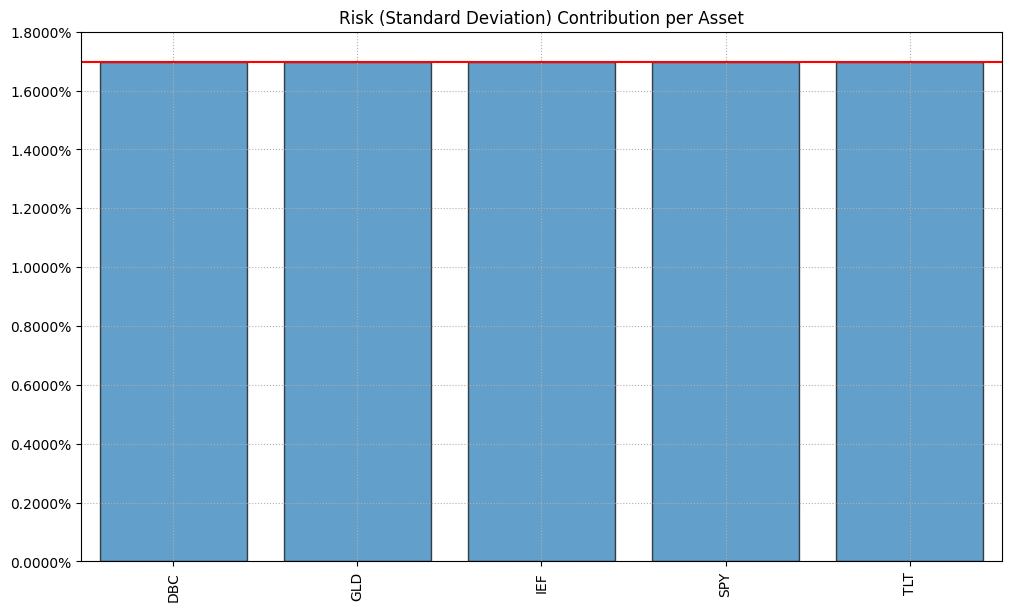

In [ ]:
# Graficando la composicion del riesgo
ax=rp.plot_risk_con(w_rp,cov=port.cov,returns=port.returns,rm=rm,rf=0,alpha=0.01)

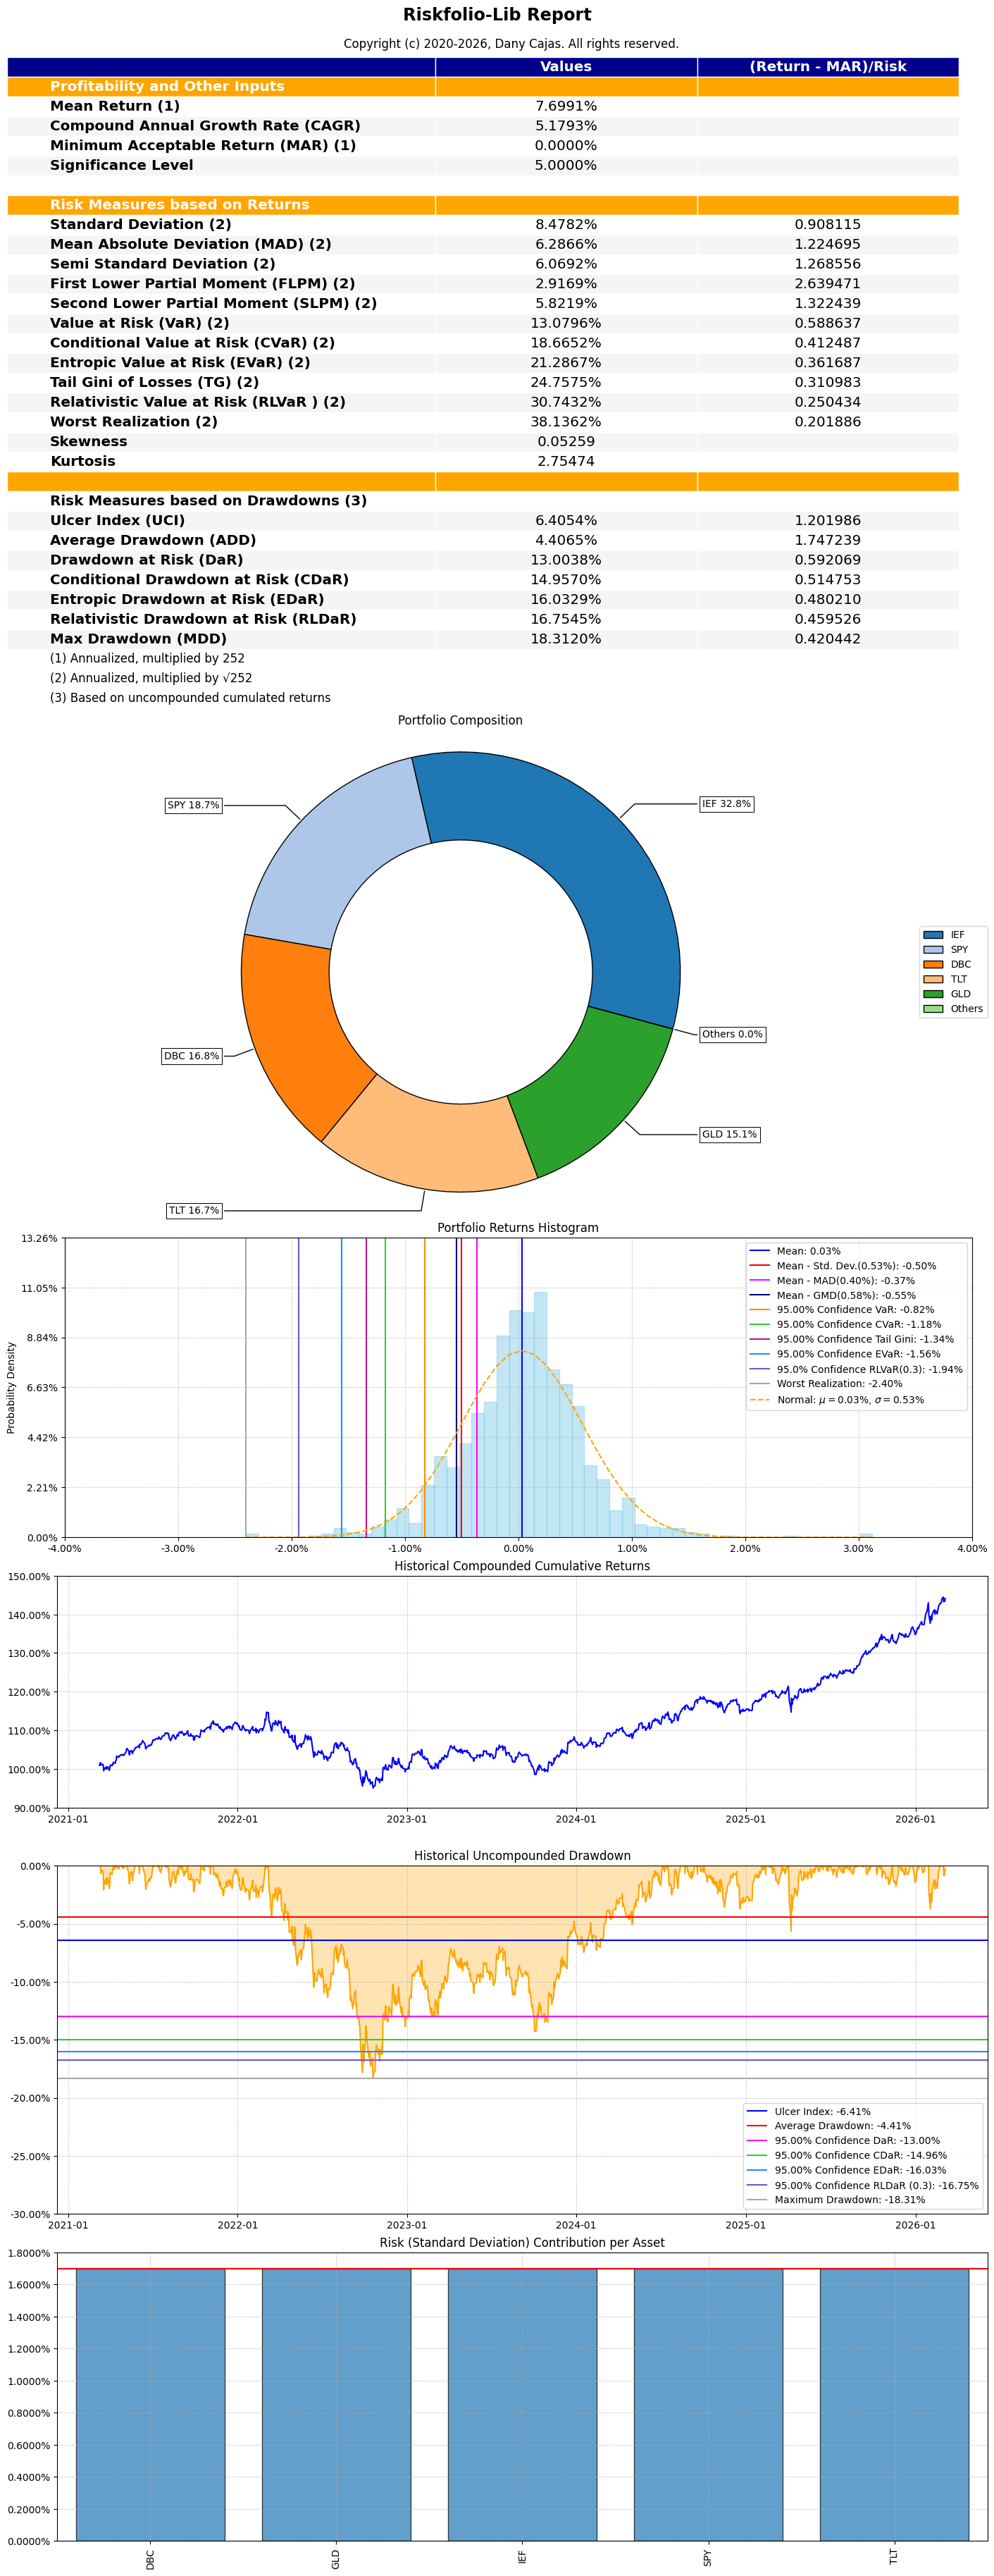

In [ ]:
ax=rp.jupyter_report(y_awp,w=w_rp,rm=rm,t_factor=252)

## Sintesis de resultados

La comparacion de las tres funciones objetivo sobre el mismo universo y la misma
matriz de covarianzas muestra lo siguiente:

| Funcion objetivo | Comportamiento de los pesos |
|---|---|
| Maximo ratio de Sharpe | Concentra en pocos activos con mejor retorno historico ajustado |
| Minimo riesgo | Se desplaza hacia renta fija y sectores defensivos, con pesos mas repartidos |
| Maximo retorno | Solucion de esquina: casi todo el peso en un solo activo |
| Risk Parity | Distribucion mas estable, sin depender de estimar retornos esperados |

El contraste entre la cartera de maximo Sharpe y la de Risk Parity es el resultado
mas informativo del ejercicio: la primera depende criticamente de que los retornos
historicos sean un buen estimador de los esperados, supuesto que rara vez se cumple.
La segunda solo requiere estimar la matriz de covarianzas, que es sustancialmente
mas estable en el tiempo.

## Limitaciones

- **Los estimadores historicos de retorno esperado son el punto debil del modelo.**
  Media-Varianza clasico es muy sensible a `mu`: cambios pequenos en el retorno
  esperado producen cambios grandes en los pesos. La solucion de esquina del
  portafolio de maximo retorno es una manifestacion directa de esto.
- **No hay restricciones de peso maximo por activo ni por sector.** Una cartera
  implementable exigiria limites de concentracion.
- **No se incorporan costos de transaccion ni politica de rebalanceo**, que en
  carteras concentradas pueden absorber buena parte de la ventaja teorica.
- **La tasa libre de riesgo se fija en cero.** Con una tasa positiva, el punto de
  tangencia de la frontera se desplaza y la cartera de maximo Sharpe cambia.
- **Todo el analisis es dentro de muestra.** No hay validacion fuera de muestra ni
  ventana rodante, de modo que el desempeno mostrado no es un pronostico.

## Que haria distinto

Reemplazar los estimadores historicos por un estimador con shrinkage (Ledoit-Wolf
para la covarianza) o incorporar vistas via Black-Litterman, y evaluar la estabilidad
de los pesos con una ventana rodante en lugar de una sola optimizacion sobre toda
la muestra.